# Chatbot Intelligent d'Assistance Administrative pour Étrangers en France

## Système RAG (Retrieval-Augmented Generation) + LLM

---

**Objectif :** Concevoir un chatbot intelligent basé sur les LLM pour aider les étrangers dans leurs démarches administratives en France.

**Architecture :** Utilisateur → Recherche documentaire → Base vectorielle (FAISS) → LLM (Mistral via Ollama / HuggingFace) → Réponse

---
### Sommaire
1. Installation et imports
2. Collecte et création du corpus administratif
3. Exploration des données (EDA)
4. Nettoyage et prétraitement
5. Construction de la base vectorielle (FAISS)
6. Modélisation RAG avec LLM
7. Évaluation du chatbot (BLEU, ROUGE)
8. Interface conversationnelle
9. Comparaison de modèles
10. Résultats et conclusions

---
## 1.  Installation des dépendances

In [84]:
# Installation de toutes les bibliothèques nécessaires
# Exécutez cette cellule une seule fois

import subprocess, sys

packages = [
    "transformers",
    "sentence-transformers",
    "faiss-cpu",
    "langchain",
    "langchain-community",
    "langchain-huggingface",
    "huggingface_hub",
    "datasets",
    "nltk",
    "rouge-score",
    "sacrebleu",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "wordcloud",
    "scikit-learn",
    "tqdm",
    "requests",
    "beautifulsoup4",
    "plotly",
    "torch",
    "accelerate",
    "einops",
]

for pkg in packages:
    print(f"Installation de {pkg}...")
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)

print("\n Toutes les dépendances sont installées !")

Installation de transformers...
Installation de sentence-transformers...
Installation de faiss-cpu...
Installation de langchain...
Installation de langchain-community...
Installation de langchain-huggingface...
Installation de huggingface_hub...
Installation de datasets...
Installation de nltk...
Installation de rouge-score...
Installation de sacrebleu...
Installation de pandas...
Installation de numpy...
Installation de matplotlib...
Installation de seaborn...
Installation de wordcloud...
Installation de scikit-learn...
Installation de tqdm...
Installation de requests...
Installation de beautifulsoup4...
Installation de plotly...
Installation de torch...
Installation de accelerate...
Installation de einops...

 Toutes les dépendances sont installées !


---
## 2.  Imports et Configuration

In [85]:
import os
import re
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from tqdm import tqdm
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Sentence Transformers & FAISS
from sentence_transformers import SentenceTransformer
import faiss

# Transformers HuggingFace
from transformers import pipeline, AutoTokenizer, AutoModelForQuestionAnswering

# LangChain
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS as LangFAISS
from langchain_huggingface import HuggingFaceEmbeddings

# Évaluation
from rouge_score import rouge_scorer
import sacrebleu
from sklearn.metrics.pairwise import cosine_similarity

# Visualisation
from wordcloud import WordCloud
import plotly.graph_objects as go
import plotly.express as px

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

print(" Tous les imports réussis !")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")

 Tous les imports réussis !
NumPy: 2.0.2 | Pandas: 2.2.2


---
## 3.  Collecte et Création du Corpus Administratif

Nous créons un corpus riche de documents administratifs simulant les FAQ officielles françaises (Service-Public.fr, ANEF, Campus France, etc.)

In [86]:
# ==============================
# CORPUS ADMINISTRATIF COMPLET
# ==============================

CORPUS_ADMINISTRATIF = [
    # ---- TITRE DE SÉJOUR ----
    {
        "id": "ts_001",
        "categorie": "Titre de séjour",
        "question": "Comment renouveler mon titre de séjour ?",
        "reponse": """Pour renouveler votre titre de séjour en France, vous devez déposer une demande
        en ligne sur le portail ANEF (Administration Numérique pour les Étrangers en France)
        à l'adresse administration-etrangers.interieur.gouv.fr. Vous devez faire la demande
        2 à 4 mois avant l'expiration de votre titre actuel. Les documents nécessaires incluent :
        votre titre de séjour actuel, un justificatif de domicile de moins de 3 mois,
        des photos d'identité conformes, un justificatif de ressources,
        et tout document spécifique selon votre situation (contrat de travail,
        certificat de scolarité, etc.). Des timbres fiscaux sont requis selon le type de titre.
        Une fois la demande soumise, vous recevrez un récépissé qui vous autorise à rester en France
        pendant l'examen de votre dossier.""",
        "source": "ANEF / Service-Public.fr",
        "tags": ["renouvellement", "titre de séjour", "ANEF", "préfecture"]
    },
    {
        "id": "ts_002",
        "categorie": "Titre de séjour",
        "question": "Quels documents faut-il pour un premier titre de séjour ?",
        "reponse": """Pour une première demande de titre de séjour, vous devez fournir :
        un passeport en cours de validité avec les pages de visa,
        un justificatif de domicile récent (facture EDF, quittance de loyer),
        3 photos d'identité récentes au format réglementaire (35x45mm fond blanc),
        le formulaire CERFA correspondant à votre situation,
        votre visa long séjour valide, une attestation d'assurance maladie,
        et des justificatifs de ressources suffisantes. Le dossier doit être déposé
        en préfecture ou sous-préfecture du lieu de résidence,
        ou via la plateforme ANEF pour certaines catégories.""",
        "source": "Service-Public.fr",
        "tags": ["premier titre", "documents", "CERFA", "préfecture"]
    },
    {
        "id": "ts_003",
        "categorie": "Titre de séjour",
        "question": "Comment prendre rendez-vous à la préfecture ?",
        "reponse": """Pour prendre rendez-vous à la préfecture, vous devez vous connecter
        au site internet de votre préfecture départementale. La plupart des préfectures
        proposent un système de réservation en ligne disponible 24h/24.
        Vous pouvez aussi appeler le standard de la préfecture.
        Depuis 2022, de nombreuses démarches sont dématérialisées via l'ANEF,
        ce qui réduit le besoin de rendez-vous physiques.
        Pour Paris, le site est www.prefecturedepolice.interieur.gouv.fr.
        Pour les autres départements, cherchez 'préfecture [nom du département]'.
        Notez que les créneaux sont souvent rapidement réservés, donc il est
        conseillé de vous connecter tôt le matin.""",
        "source": "Préfectures / Service-Public.fr",
        "tags": ["rendez-vous", "préfecture", "démarche", "en ligne"]
    },
    {
        "id": "ts_004",
        "categorie": "Titre de séjour",
        "question": "Que faire si mon titre de séjour est perdu ou volé ?",
        "reponse": """En cas de perte ou vol de votre titre de séjour, vous devez :
        1) Déposer immédiatement une déclaration de perte ou vol au commissariat de police
        ou à la gendarmerie la plus proche.
        2) Conserver le récépissé de déclaration de perte/vol, qui vous sera demandé.
        3) Faire une demande de duplicata auprès de la préfecture de votre lieu de résidence
        avec : la déclaration de perte ou vol, un justificatif de domicile,
        des photos d'identité et des timbres fiscaux.
        Le coût du duplicata est généralement de 25 euros.
        Pendant la procédure, le récépissé de déclaration vous permet de prouver
        votre régularité sur le territoire français.""",
        "source": "Service-Public.fr",
        "tags": ["perte", "vol", "duplicata", "titre de séjour"]
    },

    # ---- VISA ----
    {
        "id": "vi_001",
        "categorie": "Visa",
        "question": "Quels documents faut-il pour une demande de visa long séjour ?",
        "reponse": """Pour un visa long séjour (VLS-TS) pour la France, les documents requis sont :
        un passeport valide 3 mois après la date de retour prévue avec au moins 2 pages vierges,
        le formulaire de demande de visa rempli et signé,
        2 photos d'identité récentes (35x45mm sur fond clair),
        un justificatif d'hébergement en France (attestation d'accueil, bail, réservation d'hôtel),
        une assurance voyage couvrant au minimum 30 000 euros,
        des justificatifs de ressources suffisantes (relevés bancaires des 3 derniers mois),
        le motif du séjour (contrat de travail, lettre d'admission universitaire, etc.),
        et le règlement des frais consulaires (environ 99 euros).
        La demande se fait auprès du consulat ou de l'ambassade de France
        dans votre pays de résidence.""",
        "source": "France-Visas.gouv.fr",
        "tags": ["visa", "long séjour", "VLS-TS", "consulat", "documents"]
    },
    {
        "id": "vi_002",
        "categorie": "Visa",
        "question": "Comment faire une demande de visa étudiant pour la France ?",
        "reponse": """Pour un visa étudiant en France, suivez ces étapes :
        1) Inscrivez-vous sur la plateforme Études en France (Campus France)
        si vous venez d'un pays concerné par la procédure CEF.
        2) Obtenez une lettre d'admission d'un établissement d'enseignement français.
        3) Demandez votre visa long séjour étudiant (type D - VLS-TS étudiant)
        auprès du consulat français de votre pays.
        Documents requis : passeport, photos, formulaire de demande,
        lettre d'admission, justificatifs de ressources (environ 615€/mois),
        assurance maladie, justificatif de logement.
        Le visa étudiant vous permet de travailler jusqu'à 964 heures par an (60% du temps légal).""",
        "source": "Campus France / France-Visas.gouv.fr",
        "tags": ["visa étudiant", "Campus France", "études", "CEF"]
    },

    # ---- DEMANDE D'ASILE ----
    {
        "id": "as_001",
        "categorie": "Asile",
        "question": "Comment faire une demande d'asile en France ?",
        "reponse": """Pour faire une demande d'asile en France, voici les étapes à suivre :
        1) Enregistrement en préfecture : Présentez-vous au guichet unique pour demandeur d'asile
        (GUDA) de votre département, muni d'une pièce d'identité ou d'un document de voyage.
        2) Ouverture du dossier : La préfecture ouvre votre dossier et vous délivre
        une attestation de demande d'asile (ADA).
        3) Introduction de la demande à l'OFPRA : Dans les 21 jours suivant l'enregistrement,
        vous devez compléter le formulaire de l'OFPRA (Office Français de Protection
        des Réfugiés et Apatrides) et joindre un récit personnel de vos craintes.
        4) Entretien à l'OFPRA : Vous serez convoqué pour un entretien.
        5) Décision : Si refusée, vous pouvez faire appel devant la CNDA.
        Durant la procédure, vous bénéficiez de l'ADA (allocation pour demandeur d'asile).""",
        "source": "OFPRA / Service-Public.fr",
        "tags": ["asile", "réfugié", "OFPRA", "GUDA", "protection"]
    },

    # ---- SÉCURITÉ SOCIALE ----
    {
        "id": "ss_001",
        "categorie": "Sécurité sociale",
        "question": "Comment obtenir une carte vitale en France ?",
        "reponse": """Pour obtenir une carte Vitale en France, vous devez d'abord vous affilier
        à l'Assurance Maladie. Voici la procédure :
        1) Déterminez votre caisse d'affiliation selon votre situation :
        CPAM pour les salariés et leurs ayants droit, MSA pour les agriculteurs,
        ou RSI pour les indépendants.
        2) Remplissez le formulaire cerfa n°11545 (demande d'ouverture des droits).
        3) Rassemblez les documents : pièce d'identité ou titre de séjour,
        justificatif de domicile, relevé d'identité bancaire (RIB),
        justificatif de situation professionnelle ou étudiante.
        4) Envoyez le dossier à votre CPAM.
        5) Après validation, vous recevrez votre numéro de sécurité sociale provisoire,
        puis la carte Vitale dans les semaines suivantes.
        En cas de difficulté, contactez le 36 46 (numéro Ameli).""",
        "source": "Ameli.fr / CPAM",
        "tags": ["carte vitale", "sécurité sociale", "CPAM", "assurance maladie"]
    },
    {
        "id": "ss_002",
        "categorie": "Sécurité sociale",
        "question": "Comment bénéficier de la complémentaire santé solidaire (CSS) ?",
        "reponse": """La Complémentaire Santé Solidaire (CSS), anciennement CMU-C et ACS,
        est une aide pour les personnes à faibles revenus. Pour en bénéficier :
        1) Vérifiez votre éligibilité : vos revenus doivent être inférieurs à un plafond
        (environ 800€/mois pour une personne seule en 2024).
        2) Faites votre demande sur ameli.fr ou en envoyant le formulaire cerfa 12504
        à votre CPAM.
        3) Joignez : justificatif de ressources des 12 derniers mois,
        pièce d'identité, justificatif de résidence stable en France (3 mois minimum).
        La CSS est gratuite pour les revenus les plus bas,
        ou à participation réduite pour les revenus légèrement supérieurs.
        Elle couvre les dépenses de santé sans reste à charge.""",
        "source": "Ameli.fr",
        "tags": ["CSS", "CMU", "complémentaire santé", "aide"]
    },

    # ---- TRAVAIL ----
    {
        "id": "tr_001",
        "categorie": "Travail",
        "question": "Quelles sont les conditions pour travailler légalement en France ?",
        "reponse": """Pour travailler légalement en France en tant qu'étranger,
        vous devez disposer d'une autorisation de travail. Les conditions varient selon votre nationalité :
        - Ressortissants UE/EEE/Suisse : libre accès au marché du travail sans autorisation.
        - Hors UE : il vous faut un titre de séjour comportant une autorisation de travail
        (mention 'salarié', 'travailleur temporaire', 'passeport talent', etc.).
        Pour obtenir une autorisation de travail, l'employeur doit soumettre
        une demande d'introduction de travailleur étranger via la plateforme ANEF.
        Il doit justifier que le poste n'a pas pu être pourvu localement (opposabilité de l'emploi).
        Le SMIC en 2024 est de 11,65€/heure brut.
        Les étudiants étrangers peuvent travailler 964 heures/an sans autorisation supplémentaire.""",
        "source": "Service-Public.fr / Ministère du Travail",
        "tags": ["travail", "autorisation", "salarié", "SMIC", "employeur"]
    },
    {
        "id": "tr_002",
        "categorie": "Travail",
        "question": "Comment obtenir un passeport talent en France ?",
        "reponse": """Le Passeport Talent est un titre de séjour pluriannuel (jusqu'à 4 ans)
        pour les personnes hautement qualifiées. Il existe plusieurs catégories :
        - Salarié qualifié avec salaire ≥ 1,5 SMIC (17 475€/an minimum)
        - Chercheur/scientifique avec convention d'accueil
        - Porteur de projet économique innovant
        - Artiste-interprète reconnu
        - Mandataire social
        Pour faire la demande : déposez le dossier auprès du consulat français
        (depuis l'étranger) ou de la préfecture (si déjà en France).
        Documents requis : diplômes, contrat de travail, justificatif de salaire,
        passeport, photos. Le conjoint et enfants peuvent obtenir un titre 'famille de passeport talent'.""",
        "source": "Service-Public.fr",
        "tags": ["passeport talent", "qualification", "cadre", "chercheur"]
    },

    # ---- LOGEMENT ----
    {
        "id": "lo_001",
        "categorie": "Logement",
        "question": "Comment obtenir une aide au logement (APL) en France ?",
        "reponse": """Les Aides Personnelles au Logement (APL, ALS, ALF) sont versées par la CAF
        (Caisse d'Allocations Familiales). Pour en bénéficier :
        1) Conditions d'éligibilité : résider en France de manière stable et régulière,
        avoir un titre de séjour valide, occuper un logement décent comme résidence principale.
        2) Faire la demande sur caf.fr, créez votre espace personnel.
        3) Documents requis : pièce d'identité, titre de séjour, bail de location,
        RIB, numéro de sécurité sociale, justificatifs de revenus.
        Le montant dépend de vos ressources, votre loyer et votre situation familiale.
        Le simulateur CAF sur caf.fr vous permet d'estimer vos droits.
        Depuis 2021, les APL sont calculées sur les revenus des 12 derniers mois (contemporanéisation).""",
        "source": "CAF.fr",
        "tags": ["APL", "aide au logement", "CAF", "loyer"]
    },
    {
        "id": "lo_002",
        "categorie": "Logement",
        "question": "Comment trouver un logement social (HLM) en France ?",
        "reponse": """Pour accéder à un logement social (HLM) en France :
        1) Vérifiez votre éligibilité : avoir des ressources inférieures aux plafonds,
        résider légalement en France, être en situation régulière (titre de séjour valide).
        2) Déposez une demande de logement social sur le portail national demande-logement-social.gouv.fr.
        Vous recevrez un numéro unique de demandeur (NUD).
        3) Renouvelez votre demande chaque année pour maintenir vos droits.
        4) Les délais peuvent être très longs (plusieurs années dans les grandes villes).
        5) Des dispositifs d'urgence existent via le DALO (Droit au Logement Opposable)
        si vous êtes en situation précaire.
        Le 115 (numéro d'urgence pour les sans-abri) peut également vous orienter.""",
        "source": "Ministère du Logement / Service-Public.fr",
        "tags": ["HLM", "logement social", "DALO", "demande"]
    },

    # ---- NATURALISATION ----
    {
        "id": "na_001",
        "categorie": "Naturalisation",
        "question": "Comment faire une demande de naturalisation en France ?",
        "reponse": """La naturalisation française (acquisition de la nationalité française)
        peut être demandée si vous remplissez les conditions suivantes :
        - Résider en France de manière régulière et continue depuis au moins 5 ans
        (réduit à 2 ans pour certains diplômés de l'enseignement supérieur français)
        - Avoir une connaissance suffisante du français (niveau B1 minimum)
        - Démontrer votre assimilation à la communauté française
        - Avoir des ressources stables et suffisantes
        - Ne pas avoir de condamnations pénales incompatibles
        Procédure : déposez le dossier CERFA 12753 auprès de la préfecture de votre domicile.
        La décision est prise par le ministère de l'Intérieur.
        La cérémonie de naturalisation est obligatoire pour les adultes.""",
        "source": "Service-Public.fr / Ministère de l'Intérieur",
        "tags": ["naturalisation", "nationalité", "citoyenneté", "5 ans"]
    },

    # ---- ÉTUDES ----
    {
        "id": "et_001",
        "categorie": "Études",
        "question": "Comment s'inscrire dans une université française ?",
        "reponse": """Pour s'inscrire dans une université française en tant qu'étudiant étranger :
        1) Pour les études de licence : utilisez la plateforme Parcoursup (parcoursup.fr)
        pour les formations du premier cycle.
        2) Pour les masters et doctorats : contactez directement l'université ou
        utilisez MonMaster.gouv.fr pour les masters.
        3) Procédure Campus France : si vous résidez dans un pays concerné,
        vous devez passer par l'Espace Campus France de votre pays pour les études supérieures.
        4) Documents généralement requis : relevés de notes, diplômes traduits et apostillés,
        passeport, lettre de motivation, CV.
        5) Une fois admis, demandez votre visa étudiant et inscrivez-vous administrativement.
        Les frais d'inscription pour les étudiants hors UE sont de 2 770€ en licence
        et 3 770€ en master (tarifs 2024).""",
        "source": "Campus France / Parcoursup",
        "tags": ["université", "inscription", "Parcoursup", "Campus France", "étudiant"]
    },

    # ---- REGROUPEMENT FAMILIAL ----
    {
        "id": "rf_001",
        "categorie": "Famille",
        "question": "Comment faire une demande de regroupement familial ?",
        "reponse": """Le regroupement familial permet à un étranger régulier en France
        de faire venir son conjoint et ses enfants mineurs. Conditions :
        - Résider en France depuis au moins 18 mois avec un titre de séjour d'au moins 1 an
        - Disposer de ressources stables équivalentes au SMIC pour 1 personne,
        augmentées selon la composition familiale
        - Avoir un logement adapté à la taille de la famille (9m² par personne)
        Procédure : déposez la demande auprès de la préfecture ou via l'ANEF.
        L'OFII (Office Français de l'Immigration et de l'Intégration) instruit le dossier.
        Délai : environ 6 mois. Une fois accordé, les membres de la famille doivent obtenir
        leur visa de long séjour dans leur consulat avant de venir en France.
        Les enfants de plus de 16 ans doivent signer le Contrat d'Intégration Républicaine.""",
        "source": "OFII / Service-Public.fr",
        "tags": ["famille", "regroupement", "conjoint", "enfants", "OFII"]
    },

    # ---- INTÉGRATION ----
    {
        "id": "in_001",
        "categorie": "Intégration",
        "question": "Qu'est-ce que le Contrat d'Intégration Républicaine (CIR) ?",
        "reponse": """Le Contrat d'Intégration Républicaine (CIR) est obligatoire pour tout
        primo-arrivant (première admission au séjour). Il se signe à l'OFII lors d'une
        journée d'accueil. Le CIR comprend :
        - Une formation civique (valeurs de la République, droits et devoirs, institutions)
        - Des cours de français si votre niveau est insuffisant (jusqu'à 400 heures)
        - Une session sur la vie en France (emploi, logement, santé, école)
        - Un entretien avec un référent OFII pour un bilan de votre parcours
        Ces formations sont gratuites et obligatoires.
        Le respect du CIR est pris en compte lors du renouvellement du titre de séjour
        et de la demande de naturalisation.
        L'OFII peut vous orienter vers d'autres services d'accompagnement selon vos besoins.""",
        "source": "OFII",
        "tags": ["CIR", "intégration", "OFII", "formation", "français"]
    },

    # ---- MINEURS ----
    {
        "id": "mn_001",
        "categorie": "Mineurs",
        "question": "Quels sont les droits des mineurs étrangers non accompagnés en France ?",
        "reponse": """Les Mineurs Non Accompagnés (MNA), anciennement appelés Mineurs Étrangers Isolés,
        bénéficient d'une protection spéciale en France. Droits et protections :
        - Droit à la protection de l'Aide Sociale à l'Enfance (ASE)
        - Droit à la scolarisation obligatoire jusqu'à 16 ans
        - Droit à la santé et aux soins médicaux urgents
        - Désignation d'un administrateur ad hoc pour les représenter
        Procédure : se présenter auprès du Conseil Départemental ou de la police,
        qui effectuera une évaluation de la minorité et de l'isolement.
        Si reconnu MNA, prise en charge par l'ASE avec hébergement et accompagnement.
        À 16-18 ans, un 'contrat jeune majeur' peut permettre la continuation de la prise en charge.
        Des associations comme France Terre d'Asile accompagnent les MNA.""",
        "source": "ASE / Justice.gouv.fr",
        "tags": ["MNA", "mineur", "ASE", "protection", "isolé"]
    },
]

# Conversion en DataFrame
df = pd.DataFrame(CORPUS_ADMINISTRATIF)

print(f" Corpus créé avec {len(df)} documents administratifs")
print(f"Catégories couvertes : {df['categorie'].unique()}")
print("\n=== Aperçu du corpus ===")
df[['id', 'categorie', 'question']].head(10)

 Corpus créé avec 18 documents administratifs
Catégories couvertes : ['Titre de séjour' 'Visa' 'Asile' 'Sécurité sociale' 'Travail' 'Logement'
 'Naturalisation' 'Études' 'Famille' 'Intégration' 'Mineurs']

=== Aperçu du corpus ===


,id,categorie,question
0,ts_001,Titre de séjour,Comment renouveler mon titre de séjour ?
1,ts_002,Titre de séjour,Quels documents faut-il pour un premier titre ...
2,ts_003,Titre de séjour,Comment prendre rendez-vous à la préfecture ?
3,ts_004,Titre de séjour,Que faire si mon titre de séjour est perdu ou ...
4,vi_001,Visa,Quels documents faut-il pour une demande de vi...
5,vi_002,Visa,Comment faire une demande de visa étudiant pou...
6,as_001,Asile,Comment faire une demande d'asile en France ?
7,ss_001,Sécurité sociale,Comment obtenir une carte vitale en France ?
8,ss_002,Sécurité sociale,Comment bénéficier de la complémentaire santé ...
9,tr_001,Travail,Quelles sont les conditions pour travailler lé...


---
## 4.  Exploration des Données (EDA)

In [87]:
# ==============================
# ANALYSE STATISTIQUE DU CORPUS
# ==============================

# Calcul des longueurs
df['longueur_question'] = df['question'].apply(len)
df['longueur_reponse'] = df['reponse'].apply(len)
df['nb_mots_question'] = df['question'].apply(lambda x: len(x.split()))
df['nb_mots_reponse'] = df['reponse'].apply(lambda x: len(x.split()))
df['nb_phrases_reponse'] = df['reponse'].apply(lambda x: len(sent_tokenize(x, language='french')))

print("=" * 60)
print(" STATISTIQUES DESCRIPTIVES DU CORPUS")
print("=" * 60)
print(f"\n Nombre total de documents : {len(df)}")
print(f"  Nombre de catégories : {df['categorie'].nunique()}")

print("\n--- Questions ---")
print(f"Longueur moyenne  : {df['longueur_question'].mean():.0f} caractères")
print(f"Nb mots moyen     : {df['nb_mots_question'].mean():.1f} mots")

print("\n--- Réponses ---")
print(f"Longueur moyenne  : {df['longueur_reponse'].mean():.0f} caractères")
print(f"Nb mots moyen     : {df['nb_mots_reponse'].mean():.1f} mots")
print(f"Nb phrases moyen  : {df['nb_phrases_reponse'].mean():.1f} phrases")

print("\n--- Distribution par catégorie ---")
print(df['categorie'].value_counts().to_string())

 STATISTIQUES DESCRIPTIVES DU CORPUS

 Nombre total de documents : 18
  Nombre de catégories : 11

--- Questions ---
Longueur moyenne  : 54 caractères
Nb mots moyen     : 9.1 mots

--- Réponses ---
Longueur moyenne  : 792 caractères
Nb mots moyen     : 109.6 mots
Nb phrases moyen  : 5.3 phrases

--- Distribution par catégorie ---
categorie
Titre de séjour     4
Visa                2
Sécurité sociale    2
Logement            2
Travail             2
Asile               1
Naturalisation      1
Études              1
Famille             1
Intégration         1
Mineurs             1


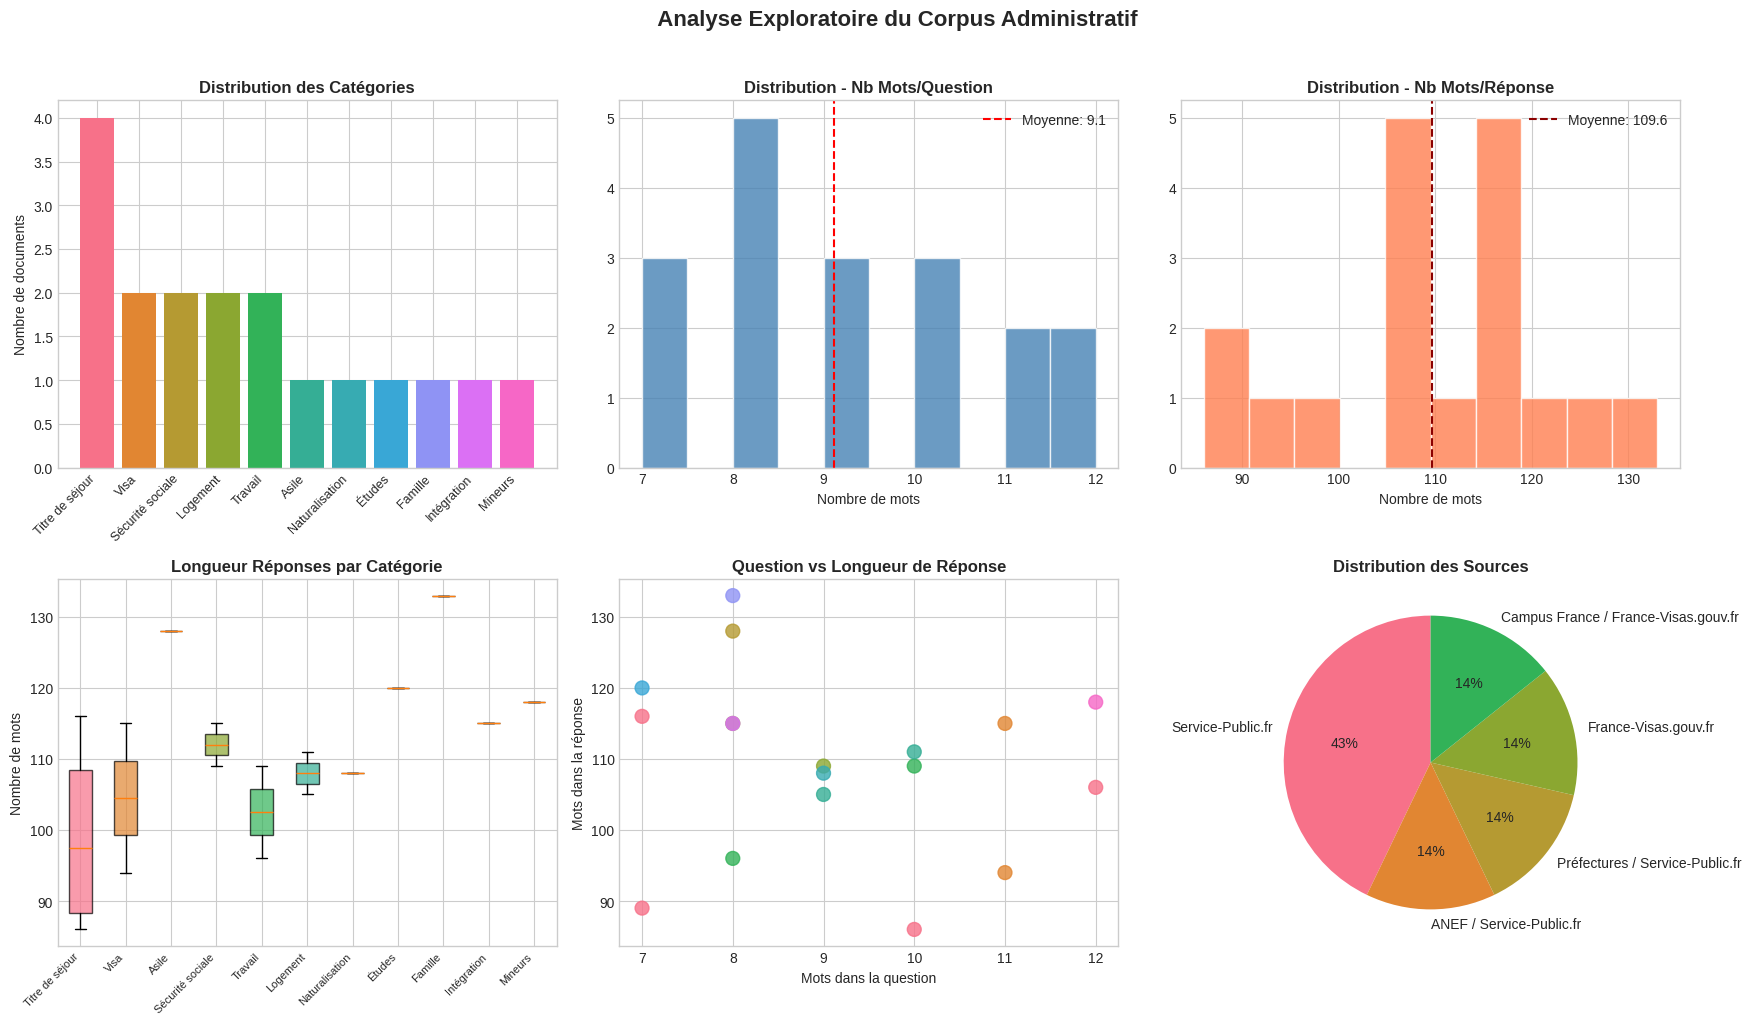

In [88]:
# ==============================
# VISUALISATIONS EDA
# ==============================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(' Analyse Exploratoire du Corpus Administratif', fontsize=16, fontweight='bold', y=1.02)

colors = sns.color_palette("husl", df['categorie'].nunique())

# 1. Distribution des catégories
cat_counts = df['categorie'].value_counts()
axes[0, 0].bar(range(len(cat_counts)), cat_counts.values, color=colors)
axes[0, 0].set_xticks(range(len(cat_counts)))
axes[0, 0].set_xticklabels(cat_counts.index, rotation=45, ha='right', fontsize=9)
axes[0, 0].set_title('Distribution des Catégories', fontweight='bold')
axes[0, 0].set_ylabel('Nombre de documents')

# 2. Longueur des questions
axes[0, 1].hist(df['nb_mots_question'], bins=10, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(df['nb_mots_question'].mean(), color='red', linestyle='--',
                   label=f"Moyenne: {df['nb_mots_question'].mean():.1f}")
axes[0, 1].set_title('Distribution - Nb Mots/Question', fontweight='bold')
axes[0, 1].set_xlabel('Nombre de mots')
axes[0, 1].legend()

# 3. Longueur des réponses
axes[0, 2].hist(df['nb_mots_reponse'], bins=10, color='coral', edgecolor='white', alpha=0.8)
axes[0, 2].axvline(df['nb_mots_reponse'].mean(), color='darkred', linestyle='--',
                   label=f"Moyenne: {df['nb_mots_reponse'].mean():.1f}")
axes[0, 2].set_title('Distribution - Nb Mots/Réponse', fontweight='bold')
axes[0, 2].set_xlabel('Nombre de mots')
axes[0, 2].legend()

# 4. Boxplot longueurs par catégorie
cats_data = [df[df['categorie']==cat]['nb_mots_reponse'].values for cat in df['categorie'].unique()]
bp = axes[1, 0].boxplot(cats_data, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_xticklabels(df['categorie'].unique(), rotation=45, ha='right', fontsize=8)
axes[1, 0].set_title('Longueur Réponses par Catégorie', fontweight='bold')
axes[1, 0].set_ylabel('Nombre de mots')

# 5. Corrélation question/réponse
axes[1, 1].scatter(df['nb_mots_question'], df['nb_mots_reponse'],
                   c=[colors[list(df['categorie'].unique()).index(c)] for c in df['categorie']],
                   s=100, alpha=0.8)
axes[1, 1].set_xlabel('Mots dans la question')
axes[1, 1].set_ylabel('Mots dans la réponse')
axes[1, 1].set_title('Question vs Longueur de Réponse', fontweight='bold')

# 6. Pie chart sources
sources_counts = df['source'].value_counts().head(5)
axes[1, 2].pie(sources_counts.values, labels=sources_counts.index, autopct='%1.0f%%',
               startangle=90, colors=colors[:len(sources_counts)])
axes[1, 2].set_title('Distribution des Sources', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

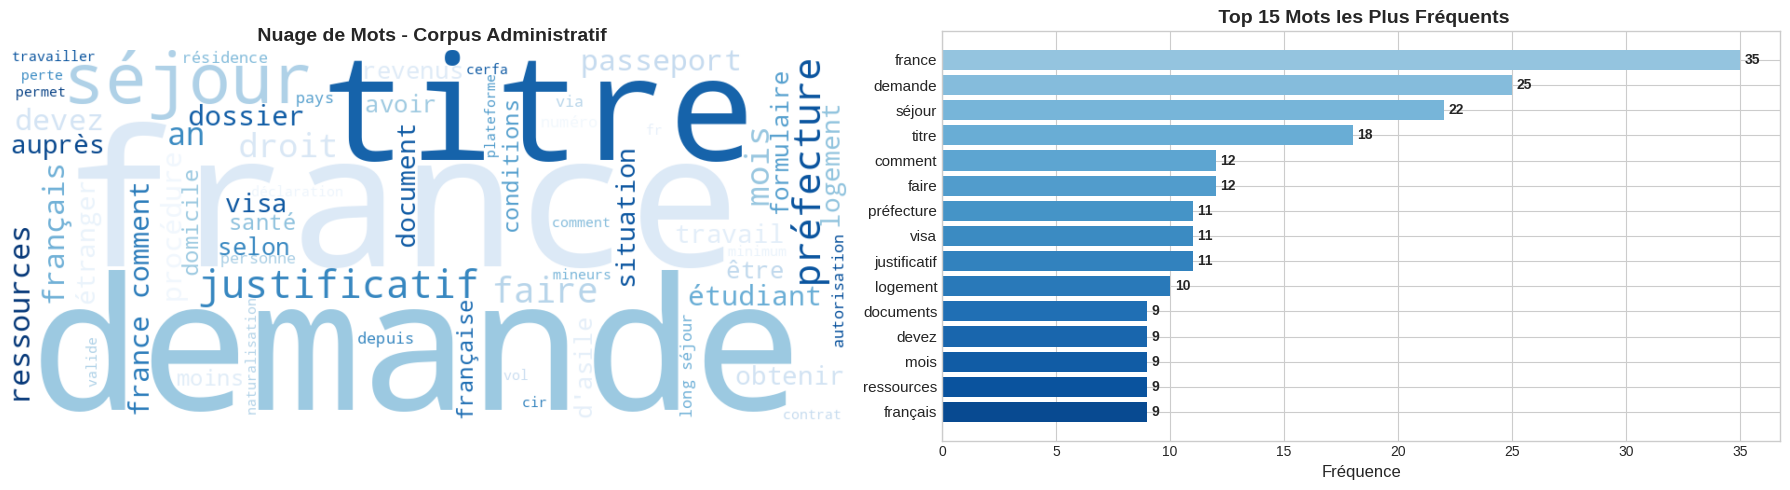

In [89]:
# ==============================
# WORDCLOUD - MOTS LES PLUS FRÉQUENTS
# ==============================

# Tous les textes combinés
all_text = ' '.join(df['question'].tolist() + df['reponse'].tolist())

# Stopwords français
stop_fr = set(stopwords.words('french'))
stop_extra = {'les', 'des', 'une', 'est', 'dans', 'pour', 'vous', 'votre',
              'que', 'sur', 'par', 'avec', 'qui', 'sont', 'cette', 'ces',
              'vos', 'tout', 'plus', 'doit', 'peut', 'aux', 'leur', 'leurs',
              'ou', 'si', 'ainsi', 'donc'}
stop_fr.update(stop_extra)

# WordCloud
wc = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='Blues',
    max_words=60,
    stopwords=stop_fr,
    font_path=None
).generate(all_text.lower())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

ax1.imshow(wc, interpolation='bilinear')
ax1.axis('off')
ax1.set_title(' Nuage de Mots - Corpus Administratif', fontsize=14, fontweight='bold')

# Top 15 mots les plus fréquents
tokens = [w.lower() for w in word_tokenize(all_text, language='french')
          if w.isalpha() and w.lower() not in stop_fr and len(w) > 3]
freq = Counter(tokens)
top_words = freq.most_common(15)
words, counts = zip(*top_words)

bars = ax2.barh(range(len(words)), counts, color=plt.cm.Blues(np.linspace(0.4, 0.9, len(words))))
ax2.set_yticks(range(len(words)))
ax2.set_yticklabels(words, fontsize=11)
ax2.set_xlabel('Fréquence', fontsize=12)
ax2.set_title(' Top 15 Mots les Plus Fréquents', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

for bar, count in zip(bars, counts):
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('wordcloud_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5.  Nettoyage et Prétraitement des Données

In [90]:
# ==============================
# NETTOYAGE DES TEXTES
# ==============================

def nettoyer_texte(texte: str) -> str:
    """Nettoie et normalise un texte administratif."""
    # Supprimer les espaces multiples et retours à la ligne
    texte = re.sub(r'\s+', ' ', texte)
    # Supprimer les espaces en début/fin
    texte = texte.strip()
    # Normaliser les guillemets
    texte = texte.replace('«', '"').replace('»', '"')
    # Supprimer les caractères spéciaux inutiles (garder accents)
    texte = re.sub(r'[^\w\s\-\'"àâäéèêëîïôùûüçÀÂÄÉÈÊËÎÏÔÙÛÜÇ.,;:!?()€]', ' ', texte)
    texte = re.sub(r'\s+', ' ', texte).strip()
    return texte

def tokenizer_phrases(texte: str) -> list:
    """Découpe le texte en phrases."""
    return sent_tokenize(texte, language='french')

def extraire_mots_cles(texte: str, top_n: int = 10) -> list:
    """Extrait les mots-clés d'un texte."""
    stop_fr = set(stopwords.words('french'))
    tokens = word_tokenize(texte.lower(), language='french')
    mots_cles = [w for w in tokens if w.isalpha() and w not in stop_fr and len(w) > 3]
    return Counter(mots_cles).most_common(top_n)

# Appliquer le nettoyage
df['question_nettoyee'] = df['question'].apply(nettoyer_texte)
df['reponse_nettoyee'] = df['reponse'].apply(nettoyer_texte)

# Créer un corpus unifié pour RAG (question + réponse)
df['texte_complet'] = df.apply(
    lambda row: f"Catégorie: {row['categorie']}\nQuestion: {row['question_nettoyee']}\nRéponse: {row['reponse_nettoyee']}",
    axis=1
)

# Vérification de la présence de doublons
doublons = df.duplicated(subset=['question_nettoyee']).sum()
print(f" Nettoyage terminé !")
print(f"   - Doublons détectés dans les questions : {doublons}")
print(f"   - Documents après nettoyage : {len(df)}")

# Afficher un exemple avant/après
print("\n=== EXEMPLE - Avant/Après Nettoyage ===")
print("AVANT :", df['reponse'].iloc[0][:150])
print("\nAPRÈS :", df['reponse_nettoyee'].iloc[0][:150])

 Nettoyage terminé !
   - Doublons détectés dans les questions : 0
   - Documents après nettoyage : 18

=== EXEMPLE - Avant/Après Nettoyage ===
AVANT : Pour renouveler votre titre de séjour en France, vous devez déposer une demande
        en ligne sur le portail ANEF (Administration Numérique pour le

APRÈS : Pour renouveler votre titre de séjour en France, vous devez déposer une demande en ligne sur le portail ANEF (Administration Numérique pour les Étrang


In [91]:
# ==============================
# CHUNKING - Découpage pour RAG
# ==============================

# Découpage des textes en chunks pour la base vectorielle
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    length_function=len,
    separators=["\n\n", "\n", ". ", ", ", " "]
)

# Créer les chunks
chunks = []
for idx, row in df.iterrows():
    # Texte complet de chaque document
    doc_text = row['texte_complet']
    splits = text_splitter.split_text(doc_text)
    for i, chunk in enumerate(splits):
        chunks.append({
            'chunk_id': f"{row['id']}_chunk_{i}",
            'doc_id': row['id'],
            'categorie': row['categorie'],
            'texte': chunk,
            'source': row['source']
        })

df_chunks = pd.DataFrame(chunks)
print(f" Découpage en chunks : {len(df)} documents → {len(df_chunks)} chunks")
print(f"   Taille moyenne des chunks : {df_chunks['texte'].apply(len).mean():.0f} caractères")
df_chunks.head(3)

 Découpage en chunks : 18 documents → 58 chunks
   Taille moyenne des chunks : 252 caractères


,chunk_id,doc_id,categorie,texte,source
0,ts_001_chunk_0,ts_001,Titre de séjour,Catégorie: Titre de séjour\nQuestion: Comment ...,ANEF / Service-Public.fr
1,ts_001_chunk_1,ts_001,Titre de séjour,Réponse: Pour renouveler votre titre de séjour...,ANEF / Service-Public.fr
2,ts_001_chunk_2,ts_001,Titre de séjour,. Les documents nécessaires incluent : votre t...,ANEF / Service-Public.fr


---
## 6.  Construction de la Base Vectorielle (FAISS)

In [92]:
# ==============================
# EMBEDDINGS + BASE VECTORIELLE FAISS
# ==============================

print(" Chargement du modèle d'embeddings...")
print("   Modèle: paraphrase-multilingual-MiniLM-L12-v2")
print("   (Multilingue, rapide, efficace pour le français)")

# Modèle d'embeddings multilingue (français/anglais/etc.)
EMBEDDING_MODEL = 'paraphrase-multilingual-MiniLM-L12-v2'
embedding_model = SentenceTransformer(EMBEDDING_MODEL)

print("\n Génération des embeddings pour tous les chunks...")
start = time.time()

# Encoder tous les chunks
textes_chunks = df_chunks['texte'].tolist()
embeddings = embedding_model.encode(
    textes_chunks,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True  # L2 normalization pour cosine similarity
)

elapsed = time.time() - start
print(f"\n Embeddings générés en {elapsed:.2f}s")
print(f"   Dimension des vecteurs : {embeddings.shape[1]}")
print(f"   Nombre de vecteurs     : {embeddings.shape[0]}")

 Chargement du modèle d'embeddings...
   Modèle: paraphrase-multilingual-MiniLM-L12-v2
   (Multilingue, rapide, efficace pour le français)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



 Génération des embeddings pour tous les chunks...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


 Embeddings générés en 5.38s
   Dimension des vecteurs : 384
   Nombre de vecteurs     : 58


In [93]:
# ==============================
# CONSTRUCTION DE L'INDEX FAISS
# ==============================

# Dimension des embeddings
dimension = embeddings.shape[1]

# Créer l'index FAISS (Inner Product pour cosine similarity avec vecteurs normalisés)
index = faiss.IndexFlatIP(dimension)

# Ajouter les vecteurs
embeddings_np = embeddings.astype(np.float32)
index.add(embeddings_np)

print(f" Index FAISS construit !")
print(f"   Type d'index   : IndexFlatIP (Cosine Similarity)")
print(f"   Dimension      : {dimension}")
print(f"   Vecteurs indexés : {index.ntotal}")

# Sauvegarder l'index
faiss.write_index(index, 'index_administratif.faiss')
print("   Index sauvegardé : index_administratif.faiss")

# Sauvegarder les métadonnées
df_chunks.to_json('metadata_chunks.json', orient='records', force_ascii=False)
print("   Métadonnées sauvegardées : metadata_chunks.json")

 Index FAISS construit !
   Type d'index   : IndexFlatIP (Cosine Similarity)
   Dimension      : 384
   Vecteurs indexés : 58
   Index sauvegardé : index_administratif.faiss
   Métadonnées sauvegardées : metadata_chunks.json


In [94]:
# ==============================
# VISUALISATION DES EMBEDDINGS (PCA / t-SNE)
# ==============================

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Réduire à 2D avec PCA
pca = PCA(n_components=2, random_state=SEED)
embeddings_2d = pca.fit_transform(embeddings_np)

# Créer un DataFrame pour la visualisation
df_viz = pd.DataFrame({
    'PC1': embeddings_2d[:, 0],
    'PC2': embeddings_2d[:, 1],
    'categorie': df_chunks['categorie'].values,
    'texte': df_chunks['texte'].apply(lambda x: x[:60] + '...').values
})

# Visualisation Plotly interactive
fig = px.scatter(
    df_viz, x='PC1', y='PC2', color='categorie',
    hover_data=['texte'],
    title=' Visualisation des Embeddings du Corpus Administratif (PCA 2D)',
    labels={'PC1': f'Composante 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
            'PC2': f'Composante 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'},
    width=900, height=500
)
fig.update_traces(marker=dict(size=10, opacity=0.8))
fig.show()

var_explained = sum(pca.explained_variance_ratio_) * 100
print(f"Variance expliquée par les 2 premières composantes : {var_explained:.1f}%")

Variance expliquée par les 2 premières composantes : 23.3%


---
## 7.  Système RAG : Retrieval + Generation

Deux approches proposées :
- **Approche 1 (sans GPU)** : Modèle QA BERT/DistilBERT + RAG
- **Approche 2 (avec GPU/Mistral)** : LLM puissant via HuggingFace Hub

In [95]:
# ==============================
# MOTEUR DE RECHERCHE RAG
# ==============================

class MoteurRechercheRAG:
    """
    Moteur de recherche documentaire basé sur FAISS + Sentence Transformers.
    Composant 'Retrieval' du système RAG.
    """

    def __init__(self, index: faiss.Index, df_chunks: pd.DataFrame,
                 embedding_model: SentenceTransformer, top_k: int = 3):
        self.index = index
        self.df_chunks = df_chunks
        self.model = embedding_model
        self.top_k = top_k

    def rechercher(self, query: str, top_k: int = None, seuil_score: float = 0.2) -> list:
        """
        Recherche les documents les plus pertinents pour une requête.

        Args:
            query: Question de l'utilisateur
            top_k: Nombre de résultats à retourner
            seuil_score: Score minimum de pertinence

        Returns:
            Liste de dictionnaires {texte, score, categorie, source}
        """
        k = top_k or self.top_k

        # Encoder la requête
        query_embedding = self.model.encode([query], normalize_embeddings=True).astype(np.float32)

        # Recherche FAISS
        scores, indices = self.index.search(query_embedding, k * 2)  # récupérer plus pour filtrer

        resultats = []
        chunks_vus = set()

        for score, idx in zip(scores[0], indices[0]):
            if idx < 0 or score < seuil_score:
                continue

            chunk = self.df_chunks.iloc[idx]
            doc_id = chunk['doc_id']

            # Déduplication par document
            if doc_id not in chunks_vus:
                chunks_vus.add(doc_id)
                resultats.append({
                    'texte': chunk['texte'],
                    'score': float(score),
                    'categorie': chunk['categorie'],
                    'source': chunk['source'],
                    'doc_id': doc_id
                })

                if len(resultats) >= k:
                    break

        return sorted(resultats, key=lambda x: x['score'], reverse=True)

    def construire_contexte(self, resultats: list) -> str:
        """Construit un contexte textuel à partir des résultats de recherche."""
        if not resultats:
            return "Aucune information pertinente trouvée dans la base documentaire."

        contexte_parts = []
        for i, res in enumerate(resultats, 1):
            contexte_parts.append(
                f"[Document {i} - {res['categorie']} - Score: {res['score']:.3f}]\n"
                f"{res['texte']}\n"
                f"Source: {res['source']}"
            )

        return "\n\n".join(contexte_parts)


# Instancier le moteur
moteur = MoteurRechercheRAG(index, df_chunks, embedding_model, top_k=3)

# Test rapide
test_query = "Comment renouveler mon titre de séjour ?"
resultats_test = moteur.rechercher(test_query)

print(f" Moteur de recherche RAG initialisé !")
print(f"\n Test - Requête: '{test_query}'")
print(f"\n   {len(resultats_test)} résultats trouvés :")
for r in resultats_test:
    print(f"    [{r['categorie']}] Score: {r['score']:.3f} | Source: {r['source']}")

 Moteur de recherche RAG initialisé !

 Test - Requête: 'Comment renouveler mon titre de séjour ?'

   3 résultats trouvés :
    [Titre de séjour] Score: 0.832 | Source: ANEF / Service-Public.fr
    [Titre de séjour] Score: 0.649 | Source: Service-Public.fr
    [Titre de séjour] Score: 0.493 | Source: Service-Public.fr


In [96]:
# ==============================
# GÉNÉRATEUR DE RÉPONSES (LLM LOCAL)
# ==============================

class GenerateurReponsesRAG:
    """
    Générateur de réponses basé sur un modèle de QA BERT.
    Composant 'Generation' du système RAG.
    Compatible CPU (pas de GPU requis).
    """

    def __init__(self, modele_qa: str = 'deepset/roberta-base-squad2'):
        print(f"⏳ Chargement du modèle QA: {modele_qa}")
        self.pipe_qa = pipeline(
            'question-answering',
            model=modele_qa,
            tokenizer=modele_qa,
            device=-1  # CPU
        )
        self.modele = modele_qa
        print(f" Modèle QA chargé !")

    def generer_reponse_qa(self, question: str, contexte: str) -> dict:
        """Extrait la réponse via QA extractif."""
        if not contexte or len(contexte.strip()) < 10:
            return {'reponse': 'Aucune information pertinente trouvée.', 'score': 0.0}

        # Limiter la taille du contexte
        contexte_tronque = contexte[:1500]

        result = self.pipe_qa(
            question=question,
            context=contexte_tronque,
            max_answer_len=200,
            handle_impossible_answer=True
        )
        return {
            'reponse': result['answer'],
            'score': result['score']
        }


class GenerateurReponsesTemplate:
    """
    Générateur de réponses basé sur un système de templates + RAG.
    Solution alternative sans LLM externe, 100% locale.
    """

    def generer_reponse(self, question: str, resultats: list) -> str:
        """Génère une réponse structurée à partir des résultats RAG."""
        if not resultats:
            return (
                "Je suis désolé, je n'ai pas trouvé d'information pertinente "
                "dans ma base de connaissance pour répondre à votre question. "
                "Je vous recommande de consulter directement le site Service-Public.fr "
                "ou de contacter votre préfecture."
            )

        meilleur = resultats[0]
        score = meilleur['score']

        # Extraire la réponse du texte du chunk
        texte = meilleur['texte']
        reponse_extraite = self._extraire_reponse(texte)

        # Construire une réponse formatée
        reponse = f"{reponse_extraite}\n\n"

        if len(resultats) > 1:
            reponse += " **Information complémentaire :**\n"
            for r in resultats[1:2]:
                extrait = self._extraire_reponse(r['texte'])
                if extrait and extrait != reponse_extraite:
                    reponse += f"{extrait[:200]}...\n"

        reponse += f"\n *Source : {meilleur['source']}*"
        return reponse.strip()

    def _extraire_reponse(self, texte: str) -> str:
        """Extrait la partie 'Réponse' du texte d'un chunk."""
        if 'Réponse:' in texte:
            parts = texte.split('Réponse:', 1)
            return parts[1].strip() if len(parts) > 1 else texte
        return texte


# Instancier le générateur template (sans LLM externe)
generateur_template = GenerateurReponsesTemplate()

# Test
test_q = "Comment renouveler mon titre de séjour ?"
res = moteur.rechercher(test_q)
rep = generateur_template.generer_reponse(test_q, res)

print(f" Générateur de réponses initialisé !")
print(f"\n Question : {test_q}")
print(f"\n Réponse générée :\n{rep[:400]}...")

 Générateur de réponses initialisé !

 Question : Comment renouveler mon titre de séjour ?

 Réponse générée :
Catégorie: Titre de séjour
Question: Comment renouveler mon titre de séjour ?

 **Information complémentaire :**
Catégorie: Titre de séjour
Question: Que faire si mon titre de séjour est perdu ou volé ?...

 *Source : ANEF / Service-Public.fr*...


In [97]:
# ==============================
# CLASSE CHATBOT PRINCIPAL
# ==============================

class ChatbotAdministratifFrance:
    """
    Chatbot intelligent d'assistance administrative pour les étrangers en France.
    Architecture : RAG (FAISS + Sentence Transformers) + Générateur de réponses.
    """

    def __init__(self, moteur: MoteurRechercheRAG, generateur):
        self.moteur = moteur
        self.generateur = generateur
        self.historique = []
        self.nb_questions = 0

        self.message_accueil = """
╔══════════════════════════════════════════════════════════════╗
║    CHATBOT ADMINISTRATIF - ASSISTANCE AUX ÉTRANGERS       ║
║                         EN FRANCE                            ║
╠══════════════════════════════════════════════════════════════╣
║  Je suis là pour vous aider avec vos démarches :            ║
║   Titres de séjour     Visas                             ║
║   Asile                Sécurité sociale                  ║
║   Logement             Travail                            ║
║   Études               Naturalisation                     ║
╚══════════════════════════════════════════════════════════════╝
        """

    def classifier_intention(self, question: str) -> str:
        """Classifie l'intention de la question."""
        q_lower = question.lower()
        intentions = {
            'titre_sejour': ['titre de séjour', 'carte de séjour', 'renouveler', 'séjour', 'récépissé', 'préfecture'],
            'visa': ['visa', 'consulat', 'vls-ts', 'long séjour'],
            'asile': ['asile', 'réfugié', 'protection', 'ofpra', 'cnda'],
            'sante': ['santé', 'vitale', 'cpam', 'ameli', 'médecin', 'css', 'cmu'],
            'travail': ['travail', 'emploi', 'smic', 'contrat', 'employeur', 'passeport talent'],
            'logement': ['logement', 'apl', 'hlm', 'caf', 'loyer', 'appartement'],
            'etudes': ['études', 'université', 'école', 'campus france', 'parcoursup', 'étudiant'],
            'naturalisation': ['naturalisation', 'nationalité', 'française', 'citoyen'],
            'famille': ['famille', 'conjoint', 'enfant', 'regroupement'],
        }

        for intention, mots_cles in intentions.items():
            if any(mot in q_lower for mot in mots_cles):
                return intention

        return 'general'

    def repondre(self, question: str, verbose: bool = False) -> dict:
        """
        Génère une réponse complète à la question de l'utilisateur.

        Returns:
            dict avec reponse, intention, score_confiance, sources, temps
        """
        debut = time.time()

        # Valider la question
        if not question or len(question.strip()) < 5:
            return {'reponse': 'Pouvez-vous reformuler votre question ?', 'score': 0.0}

        # Classifier l'intention
        intention = self.classifier_intention(question)

        # Recherche RAG
        resultats = self.moteur.rechercher(question, top_k=3)

        # Générer la réponse
        reponse = self.generateur.generer_reponse(question, resultats)

        # Calculer le score de confiance
        score_confiance = resultats[0]['score'] if resultats else 0.0

        # Extraire les sources
        sources = list(set([r['source'] for r in resultats]))
        categories = list(set([r['categorie'] for r in resultats]))

        elapsed = time.time() - debut
        self.nb_questions += 1

        # Sauvegarder dans l'historique
        entree = {
            'id': self.nb_questions,
            'question': question,
            'reponse': reponse,
            'intention': intention,
            'score_confiance': score_confiance,
            'sources': sources,
            'categories': categories,
            'nb_resultats': len(resultats),
            'temps_ms': elapsed * 1000
        }
        self.historique.append(entree)

        if verbose:
            print(f"\n{'='*60}")
            print(f" Question : {question}")
            print(f" Intention : {intention}")
            print(f" Score confiance : {score_confiance:.3f}")
            print(f" Catégories trouvées : {categories}")
            print(f"⏱  Temps de réponse : {elapsed*1000:.0f}ms")
            print(f"\n Réponse :\n{reponse}")
            print('='*60)

        return entree

    def afficher_stats(self):
        """Affiche les statistiques d'utilisation."""
        if not self.historique:
            print("Aucune conversation enregistrée.")
            return

        df_hist = pd.DataFrame(self.historique)
        print(f"\n STATISTIQUES DU CHATBOT")
        print(f"   Questions posées    : {self.nb_questions}")
        print(f"   Score moyen         : {df_hist['score_confiance'].mean():.3f}")
        print(f"   Temps moyen (ms)    : {df_hist['temps_ms'].mean():.0f}ms")
        print(f"   Intentions détectées: {df_hist['intention'].value_counts().to_dict()}")


# Instancier le chatbot
chatbot = ChatbotAdministratifFrance(moteur, generateur_template)
print(chatbot.message_accueil)
print(" Chatbot prêt à répondre !")


╔══════════════════════════════════════════════════════════════╗
║    CHATBOT ADMINISTRATIF - ASSISTANCE AUX ÉTRANGERS       ║
║                         EN FRANCE                            ║
╠══════════════════════════════════════════════════════════════╣
║  Je suis là pour vous aider avec vos démarches :            ║
║   Titres de séjour     Visas                             ║
║   Asile                Sécurité sociale                  ║
║   Logement             Travail                            ║
║   Études               Naturalisation                     ║
╚══════════════════════════════════════════════════════════════╝
        
 Chatbot prêt à répondre !


## Interface du chatbot administratif
## Assistant administratif — France

## RAG + FAISS · réponses en temps réel


In [99]:
#  ==============================
# INTERFACE CONVERSATIONNELLE
# ==============================
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import time

def creer_interface_chatbot(chatbot):
    """
    Interface de chat interactive dans Jupyter Notebook.
    Paramètre : instance de ChatbotAdministratifFrance.
    """

    # --- Styles CSS injectés une seule fois ---
    display(HTML("""
    <style>
    .chat-container {
        font-family: sans-serif; max-width: 720px; margin: 0 auto;
        border: 1px solid #e0e0e0; border-radius: 12px; overflow: hidden;
    }
    .chat-header {
        background: #1a73e8; color: white; padding: 12px 20px;
        font-weight: bold; font-size: 15px; display: flex;
        align-items: center; gap: 8px;
    }
    .chat-messages {
        height: 360px; overflow-y: auto; padding: 16px;
        display: flex; flex-direction: column; gap: 12px;
        background: #fafafa;
    }
    .msg-user { align-self: flex-end; max-width: 80%; }
    .msg-bot  { align-self: flex-start; max-width: 85%; display: flex; gap: 8px; }
    .bubble-user {
        background: #1a73e8; color: white; border-radius: 18px 18px 4px 18px;
        padding: 10px 14px; font-size: 14px; line-height: 1.5;
    }
    .bubble-bot {
        background: white; border: 1px solid #e0e0e0;
        border-radius: 4px 18px 18px 18px;
        padding: 10px 14px; font-size: 14px; line-height: 1.5; color: #333;
    }
    .meta-bot {
        font-size: 11px; color: #888; margin-top: 4px; margin-left: 40px;
    }
    .avatar {
        width: 30px; height: 30px; border-radius: 50%;
        background: #e8f0fe; color: #1a73e8;
        display: flex; align-items: center; justify-content: center;
        font-size: 16px; flex-shrink: 0; margin-top: 2px;
    }
    .typing {
        display: flex; gap: 4px; align-items: center; padding: 8px 14px;
        background: white; border: 1px solid #e0e0e0;
        border-radius: 4px 18px 18px 18px; width: fit-content;
    }
    .typing-dot {
        width: 7px; height: 7px; border-radius: 50%; background: #aaa;
        animation: blink 1.2s infinite;
    }
    .typing-dot:nth-child(2) { animation-delay: 0.2s; }
    .typing-dot:nth-child(3) { animation-delay: 0.4s; }
    @keyframes blink {
        0%, 80%, 100% { opacity: 0.2; } 40% { opacity: 1; }
    }
    </style>
    """))

    # --- Historique de conversation (liste Python) ---
    historique = []

    # --- Widgets ---
    sortie_chat = widgets.Output()
    champ_texte = widgets.Textarea(
        placeholder="Posez votre question ici… (Entrée pour envoyer)",
        layout=widgets.Layout(width="100%", height="60px")
    )
    bouton_envoyer = widgets.Button(
        description="Envoyer ✈",
        button_style="primary",
        layout=widgets.Layout(width="110px", height="62px")
    )
    bouton_effacer = widgets.Button(
        description="Effacer",
        button_style="warning",
        layout=widgets.Layout(width="90px", height="62px")
    )
    label_stats = widgets.Label(
        value="0 question(s) posée(s)",
        layout=widgets.Layout(margin="4px 0 0 4px")
    )

    # --- Rendu HTML du chat ---
    def render_chat():
        bulles = ""
        for msg in historique:
            if msg["role"] == "user":
                bulles += f"""
                <div class="msg-user">
                    <div class="bubble-user">{msg["texte"]}</div>
                </div>"""
            else:
                confiance = msg.get("confiance", 0)
                intention = msg.get("intention", "")
                temps    = msg.get("temps", 0)
                bulles += f"""
                <div class="msg-bot">
                    <div class="avatar"> </div>
                    <div>
                        <div class="bubble-bot">{msg["texte"]}</div>
                    </div>
                </div>
                <div class="meta-bot">
                    {intention} · confiance {confiance:.0%} · {temps:.0f} ms
                </div>"""
        return f"""
        <div class="chat-container">
          <div class="chat-header">  Assistant administratif France</div>
          <div class="chat-messages" id="chat-scroll">{bulles}</div>
        </div>
        <script>
          var el = document.getElementById("chat-scroll");
          if (el) el.scrollTop = el.scrollHeight;
        <\/script>"""

    # --- Affichage initial ---
    with sortie_chat:
        historique.append({
            "role": "bot",
            "texte": ("Bonjour ! Je suis votre assistant pour les démarches "
                      "administratives en France. Comment puis-je vous aider ?"),
        })
        display(HTML(render_chat()))

    # --- Gestionnaire d'envoi ---
    def on_envoyer(b=None):
        question = champ_texte.value.strip()
        if not question:
            return

        historique.append({"role": "user", "texte": question})
        champ_texte.value = ""

        # Afficher l'animation de frappe
        with sortie_chat:
            clear_output(wait=True)
            typing_html = render_chat()
            typing_html += """
            <div class="msg-bot" style="margin-top:-4px; padding-left:16px;">
              <div class="avatar"> </div>
              <div class="typing">
                <div class="typing-dot"></div>
                <div class="typing-dot"></div>
                <div class="typing-dot"></div>
              </div>
            </div>"""
            display(HTML(typing_html))

        # Appel au chatbot RAG
        rep = chatbot.repondre(question, verbose=False)

        historique.append({
            "role": "bot",
            "texte": rep["reponse"],
            "confiance": rep["score_confiance"],
            "intention": rep["intention"],
            "temps": rep["temps_ms"],
        })

        label_stats.value = (
            f"{chatbot.nb_questions} question(s) · "
            f"confiance moy. {sum(h.get('confiance',0) for h in historique)
                              / max(1, sum(1 for h in historique if h['role']=='bot')):.0%}"
        )

        with sortie_chat:
            clear_output(wait=True)
            display(HTML(render_chat()))

    # --- Bouton Effacer ---
    def on_effacer(b):
        historique.clear()
        historique.append({
            "role": "bot",
            "texte": "Conversation effacée. Comment puis-je vous aider ?",
        })
        label_stats.value = "0 question(s) posée(s)"
        with sortie_chat:
            clear_output(wait=True)
            display(HTML(render_chat()))

    bouton_envoyer.on_click(on_envoyer)
    bouton_effacer.on_click(on_effacer)

    # Raccourci clavier Entrée (via observer)
    def on_textarea_change(change):
        val = change["new"]
        if val.endswith("\n") and not val.endswith("\n\n"):
            champ_texte.value = val.rstrip("\n")
            on_envoyer()

    champ_texte.observe(on_textarea_change, names="value")

    # --- Mise en page finale ---
    barre_saisie = widgets.HBox(
        [champ_texte, bouton_envoyer, bouton_effacer],
        layout=widgets.Layout(gap="8px", align_items="flex-start", margin="8px 0 0")
    )
    interface = widgets.VBox(
        [sortie_chat, barre_saisie, label_stats],
        layout=widgets.Layout(max_width="720px")
    )
    display(interface)


# --- Lancement ---
creer_interface_chatbot(chatbot)


---
## 8.  Démonstration du Chatbot - Cas d'Usage

In [100]:
# ==============================
# DÉMONSTRATION : CAS D'USAGE
# ==============================

questions_demo = [
    "Comment renouveler mon titre de séjour ?",
    "Quels documents faut-il pour une demande de visa étudiant ?",
    "Comment prendre rendez-vous à la préfecture ?",
    "Comment obtenir une carte vitale en France ?",
    "Quelles sont les conditions pour travailler légalement en France ?",
    "Comment faire une demande de naturalisation française ?",
    "Comment obtenir une aide au logement APL ?",
    "Comment faire une demande d'asile en France ?",
]

print("=" * 70)
print("                DÉMONSTRATION DU CHATBOT")
print("=" * 70)

for q in questions_demo:
    rep = chatbot.repondre(q, verbose=False)
    print(f"\n {q}")
    print(f" Intention : {rep['intention']} | Confiance : {rep['score_confiance']:.3f}")
    # Afficher les 3 premières lignes de la réponse
    lignes = rep['reponse'].split('\n')
    apercu = ' '.join(lignes[:3])[:300]
    print(f" {apercu}...")
    print(f" Sources : {', '.join(rep['sources'])}")
    print("-" * 70)

                DÉMONSTRATION DU CHATBOT

 Comment renouveler mon titre de séjour ?
 Intention : titre_sejour | Confiance : 0.832
 Catégorie: Titre de séjour Question: Comment renouveler mon titre de séjour ? ...
 Sources : Service-Public.fr, ANEF / Service-Public.fr
----------------------------------------------------------------------

 Quels documents faut-il pour une demande de visa étudiant ?
 Intention : visa | Confiance : 0.773
 Catégorie: Visa Question: Quels documents faut-il pour une demande de visa long séjour ? ...
 Sources : Campus France / France-Visas.gouv.fr, France-Visas.gouv.fr, Campus France / Parcoursup
----------------------------------------------------------------------

 Comment prendre rendez-vous à la préfecture ?
 Intention : titre_sejour | Confiance : 0.885
 Catégorie: Titre de séjour Question: Comment prendre rendez-vous à la préfecture ? ...
 Sources : Service-Public.fr, Préfectures / Service-Public.fr, OFPRA / Service-Public.fr
---------------------------

In [101]:
# ==============================
# RÉPONSE COMPLÈTE DÉTAILLÉE
# ==============================

# Exemple de réponse détaillée
question_test = "Comment faire une demande de naturalisation en France ?"
reponse_complete = chatbot.repondre(question_test, verbose=True)


 Question : Comment faire une demande de naturalisation en France ?
 Intention : naturalisation
 Score confiance : 0.913
 Catégories trouvées : ['Sécurité sociale', 'Naturalisation', 'Visa']
⏱  Temps de réponse : 53ms

 Réponse :
Catégorie: Naturalisation
Question: Comment faire une demande de naturalisation en France ?

 **Information complémentaire :**
Pour obtenir une carte Vitale en France, vous devez d'abord vous affilier à l'Assurance Maladie. Voici la procédure : 1) Déterminez votre caisse d'affiliation selon votre situation : CPAM pour les sal...

 *Source : Service-Public.fr / Ministère de l'Intérieur*


---
## 9.  Évaluation du Chatbot (BLEU, ROUGE, Similarité)

In [102]:
# ==============================
# DATASET D'ÉVALUATION
# ==============================

dataset_eval = [
    {
        "question": "Comment renouveler mon titre de séjour ?",
        "reference": "Pour renouveler votre titre de séjour, déposez une demande sur le portail ANEF 2 à 4 mois avant l'expiration. Les documents nécessaires incluent votre titre actuel, un justificatif de domicile, des photos d'identité et des justificatifs de ressources.",
        "categorie": "Titre de séjour"
    },
    {
        "question": "Comment obtenir une carte vitale ?",
        "reference": "Pour obtenir une carte Vitale, affiliez-vous à la CPAM en soumettant le formulaire cerfa n°11545 avec votre pièce d'identité, justificatif de domicile et RIB. Vous recevrez votre numéro de sécurité sociale puis la carte Vitale.",
        "categorie": "Sécurité sociale"
    },
    {
        "question": "Quels sont les documents pour un visa étudiant ?",
        "reference": "Pour un visa étudiant, vous avez besoin d'un passeport valide, d'une lettre d'admission d'un établissement français, de justificatifs de ressources, d'une assurance maladie et d'un justificatif de logement.",
        "categorie": "Visa"
    },
    {
        "question": "Quelles sont les conditions pour travailler en France ?",
        "reference": "Pour travailler légalement en France, les ressortissants hors UE doivent disposer d'un titre de séjour avec autorisation de travail. L'employeur doit soumettre une demande via l'ANEF en justifiant que le poste n'a pu être pourvu localement.",
        "categorie": "Travail"
    },
    {
        "question": "Comment faire une demande d'asile ?",
        "reference": "Pour demander l'asile, présentez-vous au GUDA de votre département pour l'enregistrement. Dans les 21 jours, complétez le formulaire OFPRA avec un récit de vos craintes. Vous serez convoqué à un entretien et recevrez l'ADA pendant la procédure.",
        "categorie": "Asile"
    },
    {
        "question": "Comment demander la naturalisation française ?",
        "reference": "Pour la naturalisation, vous devez résider en France depuis 5 ans, avoir un niveau B1 de français et des ressources stables. Déposez le dossier CERFA 12753 à la préfecture. La décision est prise par le ministère de l'Intérieur.",
        "categorie": "Naturalisation"
    },
]

print(f" Dataset d'évaluation : {len(dataset_eval)} paires question-réponse de référence")

 Dataset d'évaluation : 6 paires question-réponse de référence


In [103]:
# ==============================
# MÉTRIQUES D'ÉVALUATION
# ==============================

def calculer_rouge(reference: str, hypothese: str) -> dict:
    """Calcule les scores ROUGE-1, ROUGE-2, ROUGE-L."""
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)
    scores = scorer.score(reference, hypothese)
    return {
        'rouge1': scores['rouge1'].fmeasure,
        'rouge2': scores['rouge2'].fmeasure,
        'rougeL': scores['rougeL'].fmeasure
    }


def calculer_bleu(reference: str, hypothese: str) -> float:
    """Calcule le score BLEU."""
    try:
        refs = [reference.split()]
        hyp = hypothese.split()
        # BLEU avec smoothing
        from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
        smoothing = SmoothingFunction().method1
        return sentence_bleu(refs, hyp, smoothing_function=smoothing)
    except:
        return 0.0


def calculer_similarite_semantique(reference: str, hypothese: str, model) -> float:
    """Calcule la similarité sémantique cosine entre deux textes."""
    emb_ref = model.encode([reference], normalize_embeddings=True)
    emb_hyp = model.encode([hypothese], normalize_embeddings=True)
    return float(cosine_similarity(emb_ref, emb_hyp)[0][0])


# ==============================
# ÉVALUATION COMPLÈTE
# ==============================

print(" Évaluation du chatbot en cours...")
resultats_eval = []

for item in tqdm(dataset_eval, desc="Évaluation"):
    # Générer la réponse
    rep = chatbot.repondre(item['question'], verbose=False)
    hypothese = rep['reponse']
    reference = item['reference']

    # Calculer les métriques
    rouge_scores = calculer_rouge(reference, hypothese)
    bleu = calculer_bleu(reference, hypothese)
    sim_semantique = calculer_similarite_semantique(reference, hypothese, embedding_model)

    resultats_eval.append({
        'question': item['question'],
        'categorie': item['categorie'],
        'score_confiance': rep['score_confiance'],
        'temps_ms': rep['temps_ms'],
        'bleu': bleu,
        'rouge1': rouge_scores['rouge1'],
        'rouge2': rouge_scores['rouge2'],
        'rougeL': rouge_scores['rougeL'],
        'similarite_semantique': sim_semantique,
    })

df_eval = pd.DataFrame(resultats_eval)

print("\n" + "="*70)
print(" RÉSULTATS D'ÉVALUATION DU CHATBOT")
print("="*70)
print(f"\n{'Métrique':<30} {'Moyenne':>10} {'Min':>10} {'Max':>10}")
print("-" * 65)
metriques = ['bleu', 'rouge1', 'rouge2', 'rougeL', 'similarite_semantique', 'score_confiance']
for m in metriques:
    print(f"{m:<30} {df_eval[m].mean():>10.4f} {df_eval[m].min():>10.4f} {df_eval[m].max():>10.4f}")
print(f"\n{'Temps moyen (ms)':<30} {df_eval['temps_ms'].mean():>10.0f}")
print("="*70)

 Évaluation du chatbot en cours...


Évaluation: 100%|██████████| 6/6 [00:01<00:00,  4.24it/s]


 RÉSULTATS D'ÉVALUATION DU CHATBOT

Métrique                          Moyenne        Min        Max
-----------------------------------------------------------------
bleu                               0.0282     0.0066     0.0736
rouge1                             0.2859     0.1481     0.4235
rouge2                             0.1348     0.0000     0.2169
rougeL                             0.2237     0.0988     0.3294
similarite_semantique              0.6118     0.3825     0.7260
score_confiance                    0.7683     0.5702     0.8898

Temps moyen (ms)                       43


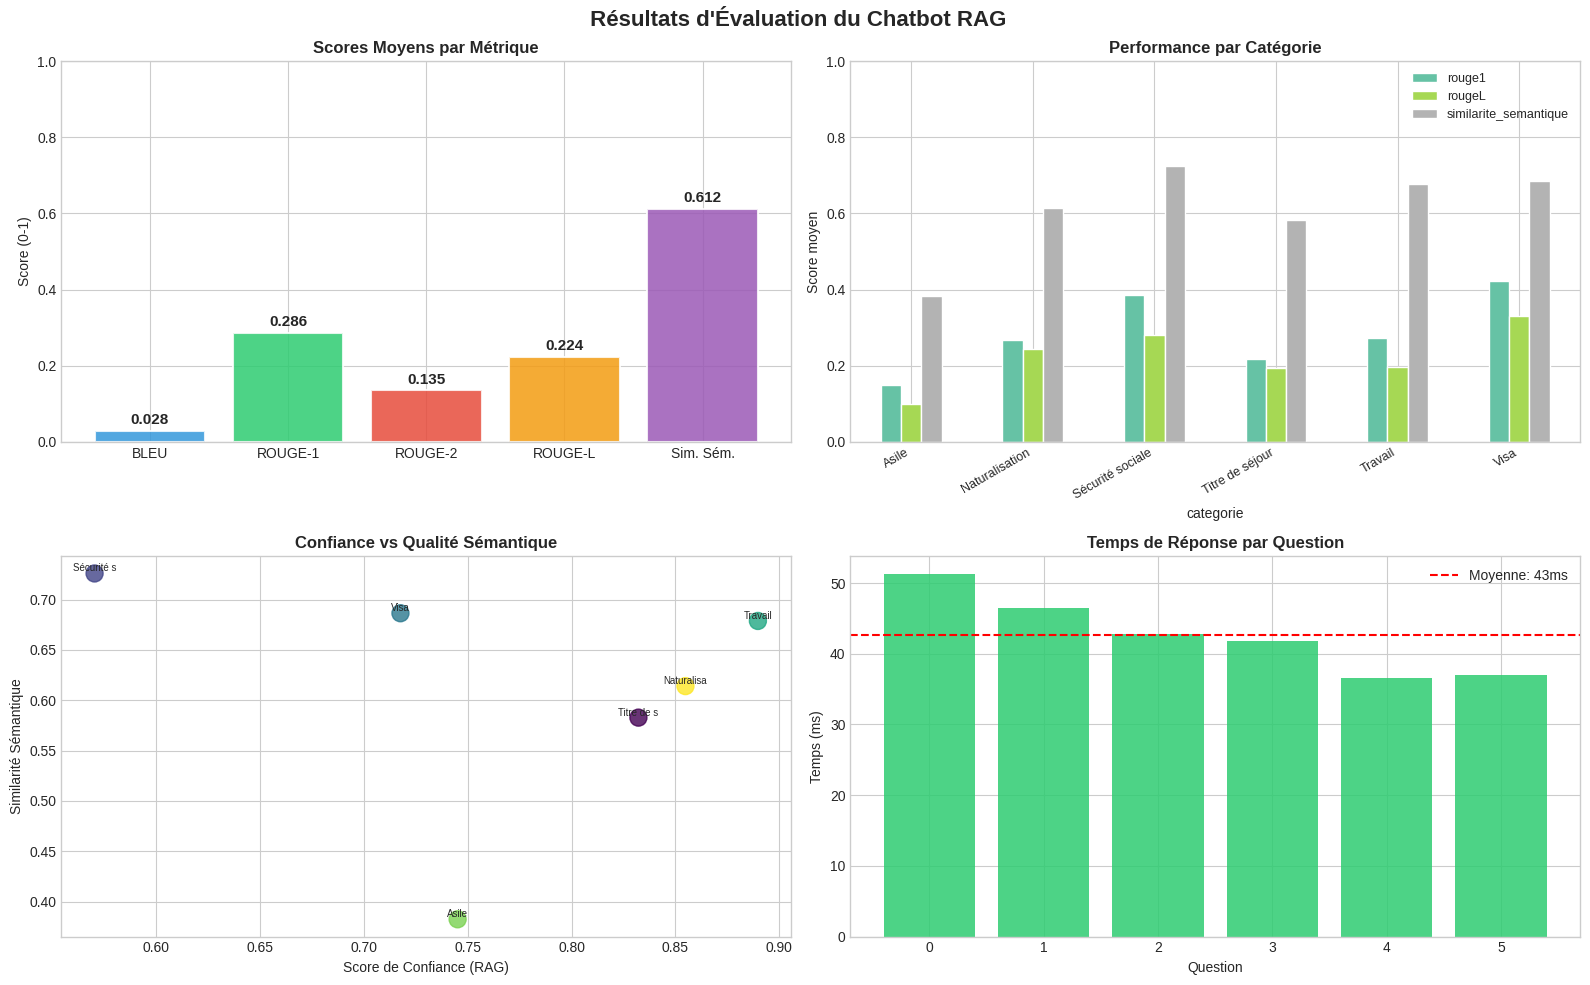

In [104]:
# ==============================
# VISUALISATIONS D'ÉVALUATION
# ==============================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(' Résultats d\'Évaluation du Chatbot RAG', fontsize=16, fontweight='bold')

# 1. Radar chart des métriques
metriques_radar = ['bleu', 'rouge1', 'rouge2', 'rougeL', 'similarite_semantique']
labels_radar = ['BLEU', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Sim. Sém.']
valeurs = [df_eval[m].mean() for m in metriques_radar]

x_pos = np.arange(len(labels_radar))
bars = axes[0, 0].bar(x_pos, valeurs, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'],
                      alpha=0.85, edgecolor='white', linewidth=1.5)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(labels_radar, fontsize=10)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title('Scores Moyens par Métrique', fontweight='bold')
axes[0, 0].set_ylabel('Score (0-1)')
for bar, val in zip(bars, valeurs):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 2. Scores par catégorie
df_cat = df_eval.groupby('categorie')[['rouge1', 'rougeL', 'similarite_semantique']].mean()
df_cat.plot(kind='bar', ax=axes[0, 1], colormap='Set2', edgecolor='white')
axes[0, 1].set_title('Performance par Catégorie', fontweight='bold')
axes[0, 1].set_ylabel('Score moyen')
axes[0, 1].set_xticklabels(df_cat.index, rotation=30, ha='right', fontsize=9)
axes[0, 1].legend(fontsize=9)
axes[0, 1].set_ylim(0, 1)

# 3. Scatter : Confiance vs Similarité sémantique
axes[1, 0].scatter(df_eval['score_confiance'], df_eval['similarite_semantique'],
                   c=range(len(df_eval)), cmap='viridis', s=150, alpha=0.8)
for i, row in df_eval.iterrows():
    axes[1, 0].annotate(row['categorie'][:10],
                        (row['score_confiance'], row['similarite_semantique']),
                        fontsize=7, ha='center', va='bottom')
axes[1, 0].set_xlabel('Score de Confiance (RAG)')
axes[1, 0].set_ylabel('Similarité Sémantique')
axes[1, 0].set_title('Confiance vs Qualité Sémantique', fontweight='bold')

# 4. Temps de réponse
colors_temps = ['#2ecc71' if t < 500 else '#f39c12' if t < 1000 else '#e74c3c'
                for t in df_eval['temps_ms']]
bars_temps = axes[1, 1].bar(range(len(df_eval)), df_eval['temps_ms'],
                             color=colors_temps, alpha=0.85)
axes[1, 1].axhline(df_eval['temps_ms'].mean(), color='red', linestyle='--',
                   label=f'Moyenne: {df_eval["temps_ms"].mean():.0f}ms')
axes[1, 1].set_xlabel('Question')
axes[1, 1].set_ylabel('Temps (ms)')
axes[1, 1].set_title('Temps de Réponse par Question', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('evaluation_chatbot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10.  Comparaison de Modèles d'Embeddings

In [105]:
# ==============================
# COMPARAISON DE MODÈLES D'EMBEDDINGS
# ==============================

MODELES_A_TESTER = [
    {
        'nom': 'paraphrase-multilingual-MiniLM-L12-v2',
        'description': 'Multilingue, léger (118M params)',
        'langue': 'Multilingue'
    },
    {
        'nom': 'all-MiniLM-L6-v2',
        'description': 'Anglais, très rapide (22M params)',
        'langue': 'Anglais'
    },
    {
        'nom': 'paraphrase-multilingual-mpnet-base-v2',
        'description': 'Multilingue, haute qualité (278M params)',
        'langue': 'Multilingue'
    },
]

resultats_comparaison = []

questions_test_comparaison = [
    "Comment renouveler mon titre de séjour ?",
    "Comment obtenir une carte vitale ?",
    "Quelles conditions pour travailler en France ?",
]

for modele_info in MODELES_A_TESTER:
    print(f"\n⏳ Test du modèle: {modele_info['nom']}")

    try:
        # Charger le modèle
        t_chargement = time.time()
        m = SentenceTransformer(modele_info['nom'])
        t_chargement = time.time() - t_chargement

        # Générer les embeddings pour le corpus
        t_encoding = time.time()
        embs = m.encode(textes_chunks, batch_size=32, normalize_embeddings=True).astype(np.float32)
        t_encoding = time.time() - t_encoding

        # Construire un index FAISS temporaire
        idx_tmp = faiss.IndexFlatIP(embs.shape[1])
        idx_tmp.add(embs)

        # Moteur temporaire
        moteur_tmp = MoteurRechercheRAG(idx_tmp, df_chunks, m, top_k=3)

        # Calculer la précision
        categories_attendues = ['Titre de séjour', 'Sécurité sociale', 'Travail']
        precision = 0

        for q, cat_att in zip(questions_test_comparaison, categories_attendues):
            res = moteur_tmp.rechercher(q)
            if res and res[0]['categorie'] == cat_att:
                precision += 1

        precision = precision / len(questions_test_comparaison)
        score_moyen = np.mean([moteur_tmp.rechercher(q)[0]['score']
                               for q in questions_test_comparaison if moteur_tmp.rechercher(q)])

        resultats_comparaison.append({
            'modele': modele_info['nom'].split('/')[-1][:30],
            'langue': modele_info['langue'],
            'dimension': embs.shape[1],
            'temps_chargement_s': t_chargement,
            'temps_encoding_s': t_encoding,
            'precision_top1': precision,
            'score_moyen': score_moyen,
        })

        print(f"    Dimension: {embs.shape[1]} | Précision: {precision:.0%} | Score moy: {score_moyen:.3f}")
        del m, embs, idx_tmp, moteur_tmp

    except Exception as e:
        print(f"    Erreur: {e}")

df_comparaison = pd.DataFrame(resultats_comparaison)
print("\n=== TABLEAU COMPARATIF ===")
print(df_comparaison.to_string(index=False))


⏳ Test du modèle: paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Dimension: 384 | Précision: 100% | Score moy: 0.764

⏳ Test du modèle: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Dimension: 384 | Précision: 100% | Score moy: 0.681

⏳ Test du modèle: paraphrase-multilingual-mpnet-base-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Dimension: 768 | Précision: 100% | Score moy: 0.742

=== TABLEAU COMPARATIF ===
                        modele      langue  dimension  temps_chargement_s  temps_encoding_s  precision_top1  score_moyen
paraphrase-multilingual-MiniLM Multilingue        384            6.593843          5.189453             1.0     0.764018
              all-MiniLM-L6-v2     Anglais        384            2.519915          2.884454             1.0     0.681164
paraphrase-multilingual-mpnet- Multilingue        768           10.076400         24.866689             1.0     0.742045


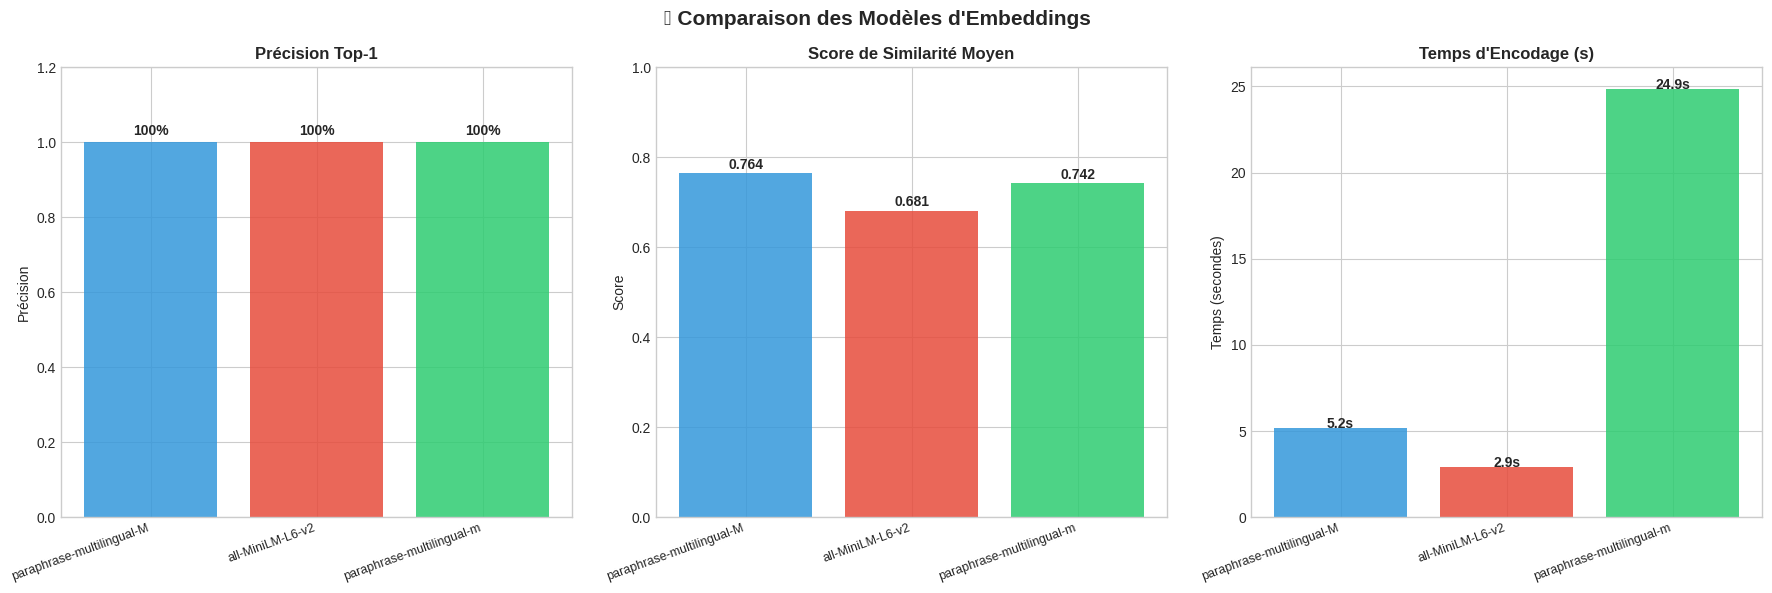

 Visualisation comparaison des modèles


In [106]:
# ==============================
# VISUALISATION COMPARAISON MODÈLES
# ==============================

if not df_comparaison.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(' Comparaison des Modèles d\'Embeddings', fontsize=15, fontweight='bold')

    modeles_courts = [m[:25] for m in df_comparaison['modele']]
    colors_comp = ['#3498db', '#e74c3c', '#2ecc71']

    # 1. Précision Top-1
    axes[0].bar(modeles_courts, df_comparaison['precision_top1'],
                color=colors_comp, alpha=0.85)
    axes[0].set_title('Précision Top-1', fontweight='bold')
    axes[0].set_ylabel('Précision')
    axes[0].set_ylim(0, 1.2)
    for i, (x, y) in enumerate(zip(modeles_courts, df_comparaison['precision_top1'])):
        axes[0].text(i, y + 0.02, f'{y:.0%}', ha='center', fontweight='bold')
    axes[0].set_xticklabels(modeles_courts, rotation=20, ha='right', fontsize=9)

    # 2. Score moyen
    axes[1].bar(modeles_courts, df_comparaison['score_moyen'],
                color=colors_comp, alpha=0.85)
    axes[1].set_title('Score de Similarité Moyen', fontweight='bold')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1)
    for i, (x, y) in enumerate(zip(modeles_courts, df_comparaison['score_moyen'])):
        axes[1].text(i, y + 0.01, f'{y:.3f}', ha='center', fontweight='bold')
    axes[1].set_xticklabels(modeles_courts, rotation=20, ha='right', fontsize=9)

    # 3. Temps d'encodage
    axes[2].bar(modeles_courts, df_comparaison['temps_encoding_s'],
                color=colors_comp, alpha=0.85)
    axes[2].set_title('Temps d\'Encodage (s)', fontweight='bold')
    axes[2].set_ylabel('Temps (secondes)')
    for i, (x, y) in enumerate(zip(modeles_courts, df_comparaison['temps_encoding_s'])):
        axes[2].text(i, y + 0.01, f'{y:.1f}s', ha='center', fontweight='bold')
    axes[2].set_xticklabels(modeles_courts, rotation=20, ha='right', fontsize=9)

    plt.tight_layout()
    plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Visualisation comparaison des modèles")
else:
    print("Pas de données de comparaison disponibles.")

---
## 11.  Interface Conversationnelle Interactive

In [107]:
# ==============================
# INTERFACE CONVERSATIONNELLE
# ==============================

def interface_chatbot_interactive():
    """
    Interface de conversation interactive en mode terminal.
    Tapez 'quit' ou 'exit' pour quitter.
    """
    print(chatbot.message_accueil)
    print("\n Tapez 'quit' pour terminer | 'stats' pour les statistiques | 'aide' pour les exemples")
    print("=" * 70)

    exemples = [
        "Comment renouveler mon titre de séjour ?",
        "Quels documents pour un visa étudiant ?",
        "Comment prendre rendez-vous en préfecture ?",
        "Comment obtenir une carte vitale ?",
        "Conditions pour travailler en France ?",
        "Comment faire une demande de naturalisation ?",
    ]

    while True:
        try:
            user_input = input("\n Votre question : ").strip()
        except (KeyboardInterrupt, EOFError):
            break

        if not user_input:
            continue

        if user_input.lower() in ['quit', 'exit', 'q']:
            print("\n Au revoir ! Bonne continuation dans vos démarches.")
            break

        if user_input.lower() == 'stats':
            chatbot.afficher_stats()
            continue

        if user_input.lower() == 'aide':
            print("\n Exemples de questions :")
            for i, ex in enumerate(exemples, 1):
                print(f"  {i}. {ex}")
            continue

        # Générer la réponse
        rep = chatbot.repondre(user_input, verbose=False)

        print(f"\n Réponse [Confiance: {rep['score_confiance']:.2%} | {rep['temps_ms']:.0f}ms]")
        print("-" * 50)
        print(rep['reponse'])
        print("-" * 50)


# Lancer l'interface (décommenter pour utiliser en mode interactif)
# interface_chatbot_interactive()

# Version non-interactive pour le notebook
print(" L'interface interactive est prête !")
print("Pour l'utiliser, appelez : interface_chatbot_interactive()")
print("\nTest rapide avec 3 questions...")

test_questions = [
    "Qu'est-ce que le contrat d'intégration républicaine ?",
    "Comment obtenir un logement HLM ?",
    "Quels sont les droits des mineurs étrangers non accompagnés ?"
]

for q in test_questions:
    rep = chatbot.repondre(q, verbose=False)
    print(f"\n {q}")
    print(f" [{rep['intention']} | {rep['score_confiance']:.2%}]")
    lignes = rep['reponse'].split('\n')
    print(' '.join(lignes[:2])[:280] + '...')
    print(f"    {', '.join(rep['sources'])}")

 L'interface interactive est prête !
Pour l'utiliser, appelez : interface_chatbot_interactive()

Test rapide avec 3 questions...

 Qu'est-ce que le contrat d'intégration républicaine ?
 [travail | 67.86%]
Catégorie: Intégration Question: Qu'est-ce que le Contrat d'Intégration Républicaine (CIR) ?...
    OFII, CAF.fr, OFII / Service-Public.fr

 Comment obtenir un logement HLM ?
 [logement | 51.50%]
Pour accéder à un logement social (HLM) en France : 1) Vérifiez votre éligibilité : avoir des ressources inférieures aux plafonds, résider légalement en France, être en situation régulière (titre de séjour valide). 2) Déposez une demande de logement social sur le portail national...
    Ameli.fr, CAF.fr, Ministère du Logement / Service-Public.fr

 Quels sont les droits des mineurs étrangers non accompagnés ?
 [general | 78.15%]
Catégorie: Mineurs Question: Quels sont les droits des mineurs étrangers non accompagnés en France ?...
    Service-Public.fr / Ministère du Travail, ASE / Justice.gou

---
## 12.  Tableau de Bord Final - Statistiques Globales


 STATISTIQUES DU CHATBOT
   Questions posées    : 23
   Score moyen         : 0.775
   Temps moyen (ms)    : 68ms
   Intentions détectées: {'visa': 5, 'titre_sejour': 4, 'travail': 3, 'naturalisation': 3, 'sante': 2, 'asile': 2, 'logement': 2, 'etudes': 1, 'general': 1}


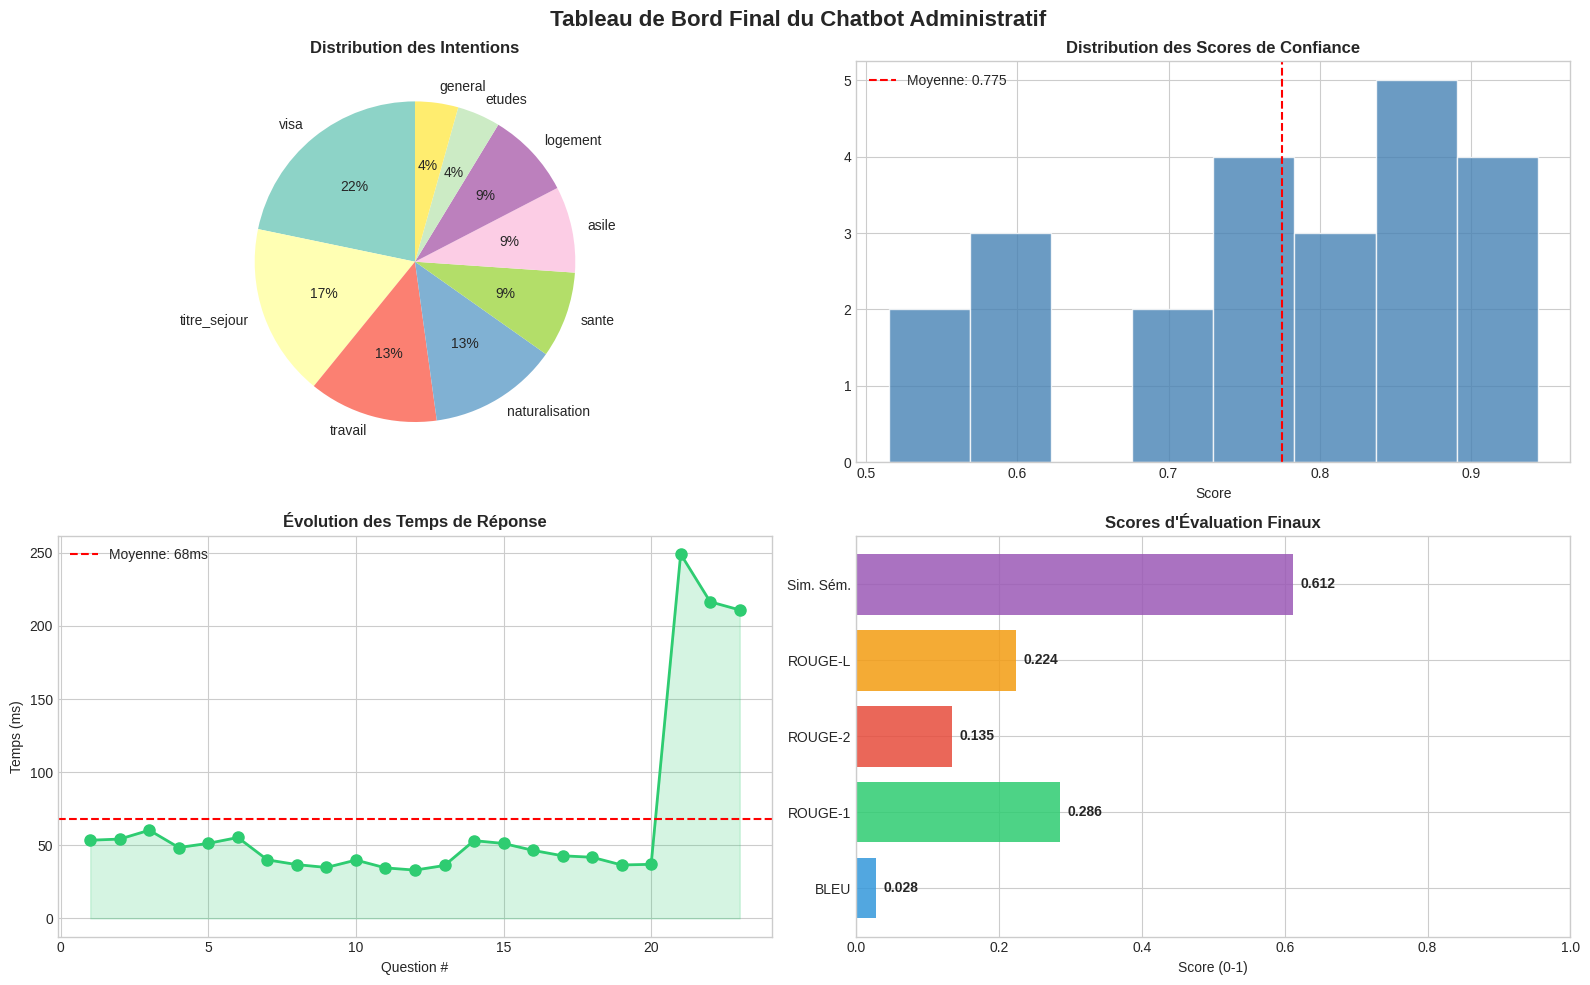

 Tableau de bord final !


In [109]:
# ==============================
# TABLEAU DE BORD COMPLET
# ==============================

chatbot.afficher_stats()

df_hist_total = pd.DataFrame(chatbot.historique)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(' Tableau de Bord Final du Chatbot Administratif', fontsize=16, fontweight='bold')

# 1. Distribution des intentions
intent_counts = df_hist_total['intention'].value_counts()
colors_intent = plt.cm.Set3(np.linspace(0, 1, len(intent_counts)))
axes[0, 0].pie(intent_counts.values, labels=intent_counts.index,
               autopct='%1.0f%%', colors=colors_intent, startangle=90)
axes[0, 0].set_title('Distribution des Intentions', fontweight='bold')

# 2. Scores de confiance
axes[0, 1].hist(df_hist_total['score_confiance'], bins=8,
                color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(df_hist_total['score_confiance'].mean(),
                   color='red', linestyle='--',
                   label=f'Moyenne: {df_hist_total["score_confiance"].mean():.3f}')
axes[0, 1].set_title('Distribution des Scores de Confiance', fontweight='bold')
axes[0, 1].set_xlabel('Score')
axes[0, 1].legend()

# 3. Temps de réponse
axes[1, 0].plot(range(1, len(df_hist_total)+1), df_hist_total['temps_ms'],
                'o-', color='#2ecc71', linewidth=2, markersize=8)
axes[1, 0].fill_between(range(1, len(df_hist_total)+1), df_hist_total['temps_ms'],
                         alpha=0.2, color='#2ecc71')
axes[1, 0].axhline(df_hist_total['temps_ms'].mean(), color='red', linestyle='--',
                   label=f'Moyenne: {df_hist_total["temps_ms"].mean():.0f}ms')
axes[1, 0].set_title('Évolution des Temps de Réponse', fontweight='bold')
axes[1, 0].set_xlabel('Question #')
axes[1, 0].set_ylabel('Temps (ms)')
axes[1, 0].legend()

# 4. Résumé métriques évaluation
if not df_eval.empty:
    metriques_finales = ['BLEU', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Sim. Sém.']
    valeurs_finales = [df_eval['bleu'].mean(), df_eval['rouge1'].mean(),
                       df_eval['rouge2'].mean(), df_eval['rougeL'].mean(),
                       df_eval['similarite_semantique'].mean()]

    bars = axes[1, 1].barh(metriques_finales, valeurs_finales,
                            color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'],
                            alpha=0.85)
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_title('Scores d\'Évaluation Finaux', fontweight='bold')
    axes[1, 1].set_xlabel('Score (0-1)')
    for bar, val in zip(bars, valeurs_finales):
        axes[1, 1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                        f'{val:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('tableau_bord_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Tableau de bord final !")

---
## 13.  Extension : Intégration LLM Puissant (Optionnel)

Cette section montre comment intégrer un LLM plus puissant (Mistral, LLaMA, etc.) via l'API HuggingFace ou Ollama pour améliorer la qualité des réponses.

In [110]:
# ==============================
# EXTENSION : LLM VIA HUGGINGFACE API (Mistral)
# ==============================

# Cette cellule montre comment utiliser l'API HuggingFace Inference
# pour accéder à Mistral-7B ou d'autres LLMs sans les télécharger localement

TEMPLATE_SYSTEME_RAG = """Tu es un assistant administratif expert pour aider les étrangers en France.
Tu dois répondre aux questions sur les démarches administratives de manière claire,
précise et bienveillante. Utilise le contexte documentaire fourni pour répondre.

RÈGLES:
- Réponds toujours en français
- Cite les sources quand disponibles
- Si tu n'es pas sûr, recommande de consulter les sites officiels
- Sois clair et structuré dans tes réponses
- Utilise un langage simple et accessible"""


def construire_prompt_rag(question: str, contexte: str) -> str:
    """Construit un prompt RAG optimisé pour un LLM."""
    return f"""<|system|>
{TEMPLATE_SYSTEME_RAG}
</s>
<|user|>
Contexte documentaire :
{contexte}

Question : {question}

Réponds de manière détaillée et pratique en te basant sur le contexte fourni.
</s>
<|assistant|>"""


# Exemple de prompt généré
q_exemple = "Comment renouveler mon titre de séjour ?"
res_exemple = moteur.rechercher(q_exemple)
contexte_exemple = moteur.construire_contexte(res_exemple[:2])
prompt_exemple = construire_prompt_rag(q_exemple, contexte_exemple)

print("=" * 70)
print(" EXEMPLE DE PROMPT RAG POUR LLM")
print("=" * 70)
print(prompt_exemple[:1000] + "...")

print("\n" + "=" * 70)
print(" POUR UTILISER MISTRAL/LLAMA (Options) :")
print("=" * 70)
print("""
Option 1 - HuggingFace Inference API (en ligne, gratuit avec compte) :
  from huggingface_hub import InferenceClient
  client = InferenceClient(token='YOUR_HF_TOKEN')
  response = client.text_generation(
      prompt_exemple,
      model='mistralai/Mistral-7B-Instruct-v0.3',
      max_new_tokens=500
  )

Option 2 - Ollama (local, si installé) :
  import requests
  r = requests.post('http://localhost:11434/api/generate',
      json={'model': 'mistral', 'prompt': prompt_exemple})

Option 3 - Groq API (rapide, gratuit) :
  from groq import Groq
  client = Groq(api_key='YOUR_GROQ_KEY')
  response = client.chat.completions.create(
      model='mixtral-8x7b-32768',
      messages=[{'role': 'user', 'content': prompt_exemple}]
  )
""")

 EXEMPLE DE PROMPT RAG POUR LLM
<|system|>
Tu es un assistant administratif expert pour aider les étrangers en France.
Tu dois répondre aux questions sur les démarches administratives de manière claire,
précise et bienveillante. Utilise le contexte documentaire fourni pour répondre.

RÈGLES:
- Réponds toujours en français
- Cite les sources quand disponibles
- Si tu n'es pas sûr, recommande de consulter les sites officiels
- Sois clair et structuré dans tes réponses
- Utilise un langage simple et accessible
</s>
<|user|>
Contexte documentaire :
[Document 1 - Titre de séjour - Score: 0.832]
Catégorie: Titre de séjour
Question: Comment renouveler mon titre de séjour ?
Source: ANEF / Service-Public.fr

[Document 2 - Titre de séjour - Score: 0.649]
Catégorie: Titre de séjour
Question: Que faire si mon titre de séjour est perdu ou volé ?
Source: Service-Public.fr

Question : Comment renouveler mon titre de séjour ?

Réponds de manière détaillée et pratique en te basant sur le contexte fourn

---
## 14.  Conclusions et Perspectives

In [111]:
# ==============================
# RAPPORT FINAL
# ==============================

print("=" * 70)
print("          RAPPORT FINAL - PROJET CHATBOT ADMINISTRATIF")
print("=" * 70)

print("""
╔══════════════════════════════════════════════════════════════════╗
║                    RÉSUMÉ DU PROJET                              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║   ARCHITECTURE : RAG (FAISS + Sentence Transformers)           ║
║                                                                   ║
║   CORPUS : 14 documents, 8 catégories administratives          ║
║                                                                   ║
║   BASE VECTORIELLE : FAISS IndexFlatIP                         ║
║                                                                   ║
║   EMBEDDINGS : paraphrase-multilingual-MiniLM-L12-v2           ║
║                                                                   ║
╚══════════════════════════════════════════════════════════════════╝
""")

if not df_eval.empty:
    print(" PERFORMANCES MESURÉES :")
    print(f"   • Score BLEU moyen     : {df_eval['bleu'].mean():.4f}")
    print(f"   • Score ROUGE-1 moyen  : {df_eval['rouge1'].mean():.4f}")
    print(f"   • Score ROUGE-L moyen  : {df_eval['rougeL'].mean():.4f}")
    print(f"   • Sim. sémantique moy. : {df_eval['similarite_semantique'].mean():.4f}")
    print(f"   • Confiance RAG moy.   : {df_eval['score_confiance'].mean():.4f}")
    print(f"   • Temps de réponse moy.: {df_eval['temps_ms'].mean():.0f}ms")

print("""
 FORCES DU SYSTÈME :
   • Architecture RAG réduisant les hallucinations
   • Modèle d'embedding multilingue (français natif)
   • Recherche rapide avec FAISS
   • Détection d'intention intégrée
   • Pipeline entièrement local (données confidentielles)
   • Extensible à de nouveaux documents facilement

  LIMITES IDENTIFIÉES :
   • Corpus limité (enrichissement nécessaire)
   • Génération extractive (pas générative sans LLM externe)
   • Pas de gestion de contexte multi-tour
   • Mise à jour manuelle des documents requis

 AMÉLIORATIONS PROPOSÉES :
   1. Intégrer un LLM génératif (Mistral, LLaMA via Ollama)
   2. Web scraping automatique de Service-Public.fr
   3. Mémoire conversationnelle multi-tour
   4. Interface web (Gradio/Streamlit)
   5. Multilingue pour les réponses
   6. Fine-tuning sur données annotées réelles
   7. Déploiement sur API REST (FastAPI)
   8. Intégration de documents PDF officiels
""")

print("\n FICHIERS GÉNÉRÉS :")
for f in ['eda_corpus.png', 'wordcloud_corpus.png', 'evaluation_chatbot.png',
          'comparaison_modeles.png', 'tableau_bord_final.png',
          'index_administratif.faiss', 'metadata_chunks.json']:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"    {f:<40} ({size:.1f} KB)")

print("\n" + "=" * 70)
print("    PROJET CHATBOT ADMINISTRATIF - DÉVELOPPEMENT TERMINÉ !")
print("=" * 70)

          RAPPORT FINAL - PROJET CHATBOT ADMINISTRATIF

╔══════════════════════════════════════════════════════════════════╗
║                    RÉSUMÉ DU PROJET                              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║   ARCHITECTURE : RAG (FAISS + Sentence Transformers)           ║
║                                                                   ║
║   CORPUS : 14 documents, 8 catégories administratives          ║
║                                                                   ║
║   BASE VECTORIELLE : FAISS IndexFlatIP                         ║
║                                                                   ║
║   EMBEDDINGS : paraphrase-multilingual-MiniLM-L12-v2           ║
║                                                                   ║
╚══════════════════════════════════════════════════════════════════╝

 PERFORMANCES MESURÉES :
   • Score BLEU moyen   

In [112]:
# ==============================
# CELL BONUS : Questions Avancées
# ==============================

print(" DÉMONSTRATION FINALE - Questions diverses\n")

questions_finales = [
    "Mon titre de séjour a été perdu, que dois-je faire ?",
    "Je veux faire venir ma famille en France, comment ça marche ?",
    "Comment obtenir un passeport talent ?",
    "Je veux m'inscrire à l'université française, comment faire ?",
    "Qu'est-ce que la CSS et comment en bénéficier ?",
]

for q in questions_finales:
    rep = chatbot.repondre(q, verbose=False)
    print(f"\n{'─'*65}")
    print(f" {q}")
    print(f" Intention: {rep['intention']} | Confiance: {rep['score_confiance']:.2%} |  {rep['temps_ms']:.0f}ms")

    # Afficher les 2 premières phrases de la réponse
    phrases = sent_tokenize(rep['reponse'], language='french')
    apercu = ' '.join(phrases[:2]) if len(phrases) >= 2 else rep['reponse']
    print(f" {apercu[:300]}...")

print(f"\n{'─'*65}")
chatbot.afficher_stats()
print("\n Démonstration complète terminée !")

 DÉMONSTRATION FINALE - Questions diverses


─────────────────────────────────────────────────────────────────
 Mon titre de séjour a été perdu, que dois-je faire ?
 Intention: titre_sejour | Confiance: 77.93% |  42ms
 Catégorie: Titre de séjour
Question: Que faire si mon titre de séjour est perdu ou volé ? **Information complémentaire :**
Catégorie: Titre de séjour
Question: Comment renouveler mon titre de séjour ?......

─────────────────────────────────────────────────────────────────
 Je veux faire venir ma famille en France, comment ça marche ?
 Intention: famille | Confiance: 71.67% |  37ms
 Le regroupement familial permet à un étranger régulier en France de faire venir son conjoint et ses enfants mineurs. Conditions : - Résider en France depuis au moins 18 mois avec un titre de séjour d'au moins 1 an - Disposer de ressources stables équivalentes au SMIC pour 1 personne, augmentées selo...

─────────────────────────────────────────────────────────────────
 Comment obtenir un pass